[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Python-for-AI-Driven-Automation/blob/main/07_industry_applications/A14_bandits_adaptive.ipynb)

> 📎 **Appendix notebook — full-lesson style.** Module 7's fourteenth appendix (see `README.md`), written like the module's core notebooks: same rhythm, same ✋/🧪/🧠 ladder. It runs on the core course stack (`numpy`, `pandas`, `matplotlib`, `seaborn`) with all data generated inline — 100 % offline.

---
# 📓 Notebook A14 (IA) — Bandits & Adaptive Allocation: Learning While You Earn

> **Module:** Industry Applications · **Type:** Appendix · **Estimated time:** ~2 h 45 m · **Difficulty:** ⭐⭐ (stretch ⭐⭐⭐)

This module's longest thread ends here. **NB 23** targeted a retention offer with a model. **A3** discovered that the lender's own approvals had written its training data. **A4** showed what targeted data does to an estimator — the same code, the same features, the wrong sign. **A2** fixed all of it with a coin flip, and closed on a memo. This notebook picks up the one line of that memo nobody costed: *while the experiment runs, half your traffic is deliberately being shown something you already suspect is worse.*

The webshop's homepage **hero slot** shows exactly one of **six offers**, to roughly **4,000 sessions a day**, all year. The merchandising team's process is the one A2 taught them: a **4-week equal-split A/B/n test** every quarter, then ship the winner. It is a good process. It is also an invoice, and nobody has ever added it up. The question this notebook answers is the one A2 deliberately left open: **you are paying for the learning — how much, and can you pay less?**

The answer is yes, by a factor of five or so, and the way you do it is to let the allocation itself react to the data as it arrives. That is a **multi-armed bandit**. And then the twist that earns this notebook its place in *this* module rather than in a generic ML course: making the randomization adaptive fixes the cost and **re-breaks the inference**. A2 randomized to buy an unbiased number; §3 hands that number back.

> 🧠 **Mental model.** In an experiment, allocation is a *design*: fixed in advance, ignorable at analysis time, which is exactly what makes the estimate clean. In a bandit, allocation is a *decision*: it depends on everything you have seen, so every session is simultaneously a measurement and a sale, and the two jobs pull in opposite directions. **Regret** — euros of margin foregone versus always having played the best offer — is the price of the measurement. Bandits do not abolish that price; they choose to spend it where it is cheapest, and they send you the bill in a different currency: your estimates.

## 🎯 Learning objectives

By the end you can:

1. Express a "which version wins?" question as a **bandit** — arms, rewards in euros, horizon — and price a fixed A/B/n test as **cumulative regret** rather than as a p-value.
2. Implement **ε-greedy**, **UCB1** and **Beta-Bernoulli Thompson sampling** from scratch, run seeded replications, and read a cumulative-regret plot with uncertainty bands.
3. Explain and *measure* **adaptive-sampling bias**: why a bandit's naive per-arm means are systematically wrong, which direction the error runs, and what it does to a lift number someone will put in a business case.
4. Apply the rule that follows from it — **bandits optimise, experiments estimate** — to real briefs, and say which deliverable requires which design.
5. Build a **contextual (per-segment) bandit**, price the personalisation gain in euros, warm-start it from an offline model, and defend it with an **exploration floor** when the prior is wrong.
6. Say when a bandit is the **wrong** tool — delayed rewards, non-stationarity, too few decisions, organisational legibility — with a number attached to each, not a shrug.

## ✅ Prerequisites

**A2** (experiments; this notebook is its direct sequel and reuses its winner's-curse frame), **A4** (§4 is the bridge back to it), and **A3 §6** (the randomized exploration budget, which returns here in a new costume). **NB 25** for the B2B webshop whose homepage this is, and **NB 10** for confidence intervals. All data is generated inline; everything runs offline.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 120)

SESSIONS_DAY = 4_000          # hero-slot sessions per day
QUARTER_DAYS = 90             # the planning horizon everything is priced over
TEST_DAYS = 28                # today's process: a 4-week equal-split A/B/n test
BATCH = 200                   # the serving layer refreshes the split every 200 sessions
BATCH_DAY = SESSIONS_DAY // BATCH          # 20 refreshes per day
B_QUARTER = QUARTER_DAYS * BATCH_DAY       # batches in a quarter
B_TEST = TEST_DAYS * BATCH_DAY             # batches in the 4-week test
SESSIONS_Q = SESSIONS_DAY * QUARTER_DAYS
REPS = 60                     # parallel simulated quarters, for uncertainty bands

print(f"{SESSIONS_DAY:,} sessions/day -> {SESSIONS_Q:,} hero-slot impressions per quarter, "
      f"allocated in {B_QUARTER:,} batches of {BATCH}.")

4,000 sessions/day -> 360,000 hero-slot impressions per quarter, allocated in 1,800 batches of 200.


## 1. Six offers, one hero slot, and the price of learning

The webshop from NB 25 and A1 has one piece of real estate that matters: the **hero slot** at the top of the homepage. Every session sees exactly one offer there, and merchandising has six candidates this quarter — four new creatives plus **F**, last quarter's shipped winner, which is still live by default.

The process is A2's, run properly: every quarter, split traffic six ways for four weeks, measure, ship the winner. Nothing about that is wrong. But notice what it *costs*, and notice that the cost never appears on any dashboard: for 28 days, five sixths of your traffic is shown something that — the moment the test is over — you will declare worse.

The unit of account for the rest of this notebook is **regret**:

$$\text{Regret}(T) \;=\; \sum_{t=1}^{T} \Big( v_{a^*} - v_{a_t} \Big)$$

where $v_a$ is the expected **euros of margin per session** from offer $a$, $a^*$ is the best offer, and $a_t$ is what you actually showed at session $t$. It is not a statistic; it is a P&L line — *margin you could have had and didn't*, measured against the omniscient policy of always playing the best arm. Every design in this notebook gets priced in it.

One deliberate trap in the setup, and it is the module's oldest lesson wearing new clothes: the six offers have **different margins per conversion**. A bundle converts rarely and pays richly; free delivery converts often and pays thin. So the offer with the best *conversion rate* is not the offer with the best *euros*, and any system that optimises clicks will confidently walk away from the money. (You will debug exactly that in 🧪 Exercise 3.)

                                offer  cvr  margin  eur_per_session  eur_per_quarter
A       A · 10 % off your first order  3.4    18.0            0.612         220320.0
B          B · free next-day delivery  4.1    14.0            0.574         206640.0
C          C · printer + toner bundle  2.2    41.0            0.902         324720.0
D       D · EUR 5 voucher over EUR 50  3.8    16.5            0.627         225720.0
E        E · new-season office chairs  2.6    29.0            0.754         271440.0
F  F · 15 % off clearance (incumbent)  3.0    21.0            0.630         226800.0

best CONVERSION RATE : offer B (4.1%)
best EURO VALUE      : offer C (EUR 0.902/session, EUR 324,720/quarter)
gap to the runner-up : EUR 0.148/session


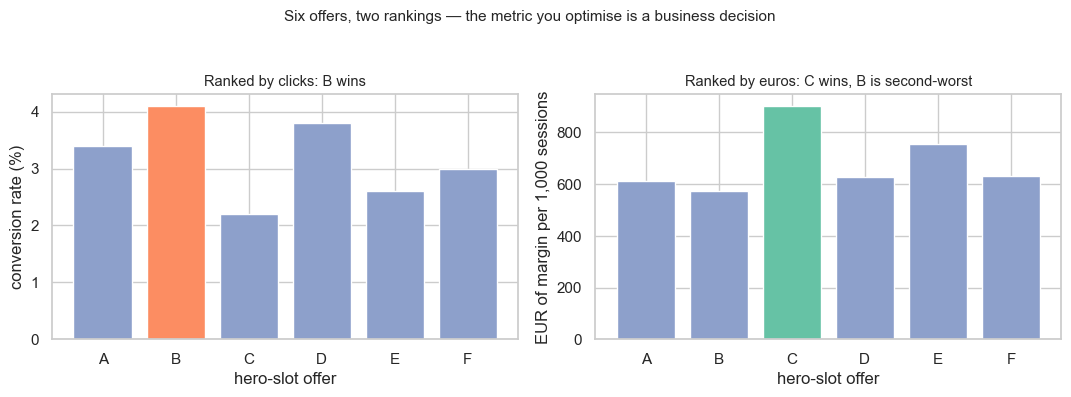

In [2]:
# The six candidate offers. In production these numbers are unknown -- we plant
# them so the notebook can score every policy against a truth it controls.
OFFERS = pd.DataFrame({
    "offer": ["A · 10 % off your first order",
              "B · free next-day delivery",
              "C · printer + toner bundle",
              "D · EUR 5 voucher over EUR 50",
              "E · new-season office chairs",
              "F · 15 % off clearance (incumbent)"],
    "cvr":    [0.034, 0.041, 0.022, 0.038, 0.026, 0.030],   # true conversion rate
    "margin": [18.00, 14.00, 41.00, 16.50, 29.00, 21.00],   # EUR contribution per conversion
}, index=list("ABCDEF"))
OFFERS["eur_per_session"] = OFFERS.cvr * OFFERS.margin
OFFERS["eur_per_quarter"] = OFFERS.eur_per_session * SESSIONS_Q

P_TRUE = OFFERS.cvr.to_numpy()
MARGIN = OFFERS.margin.to_numpy()
VALUE = P_TRUE * MARGIN                      # EUR per session, per offer
BEST = int(VALUE.argmax())
K = len(P_TRUE)

print(OFFERS.assign(cvr=lambda d: (d.cvr * 100).round(2)).round(3).to_string())
print(f"\nbest CONVERSION RATE : offer {OFFERS.index[P_TRUE.argmax()]} "
      f"({P_TRUE.max():.1%})")
print(f"best EURO VALUE      : offer {OFFERS.index[BEST]} "
      f"(EUR {VALUE[BEST]:.3f}/session, EUR {VALUE[BEST] * SESSIONS_Q:,.0f}/quarter)")
print(f"gap to the runner-up : EUR {VALUE[BEST] - np.sort(VALUE)[-2]:.3f}/session")

# FIG 1 -- the same six offers, ranked two ways
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
col_rate = ["#8da0cb" if i != P_TRUE.argmax() else "#fc8d62" for i in range(K)]
col_eur = ["#8da0cb" if i != BEST else "#66c2a5" for i in range(K)]
axes[0].bar(OFFERS.index, P_TRUE * 100, color=col_rate)
axes[0].set_ylabel("conversion rate (%)")
axes[0].set_title("Ranked by clicks: B wins", fontsize=10.5)
axes[1].bar(OFFERS.index, VALUE * 1000, color=col_eur)
axes[1].set_ylabel("EUR of margin per 1,000 sessions")
axes[1].set_title("Ranked by euros: C wins, B is second-worst", fontsize=10.5)
for ax in axes:
    ax.set_xlabel("hero-slot offer")
plt.suptitle("Six offers, two rankings — the metric you optimise is a business decision",
             fontsize=11, y=1.04)
plt.tight_layout()
plt.show()

Offer **B** converts at 4.1 %, the best of the six, and returns **€0.574 per session** — fifth out of six. Offer **C** converts at 2.2 %, the *worst* of the six, and returns **€0.902**, because a printer-and-toner bundle carries €41 of contribution and a free-delivery promo carries €14. A conversion-rate dashboard would ship B and quietly hand back €0.33 per session, which at this traffic is **€118k a quarter**.

So the first decision in any bandit is not which algorithm to use. It is **what counts as a reward** — and the answer is always the thing your P&L is denominated in. NB 24 made the same point with its alert queue (a caught €12 fraud is not a caught €12,000 one), A6 with its collections ranking, A4 with its break-even uplift. Here it comes back as a one-line choice inside a sampler.

Now let's price the three policies the business already has.

In [3]:
gap_uniform = VALUE[BEST] - VALUE.mean()      # EUR/session lost by a 1/6 split
print(f"an equal 1/6 split gives up EUR {gap_uniform:.4f} per session\n")

# --- baseline 1: keep showing last quarter's winner, offer F ---
keep_f = (VALUE[BEST] - VALUE[5]) * SESSIONS_Q

# --- baseline 2: split all quarter (never decide) ---
split_all = gap_uniform * SESSIONS_Q

# --- baseline 3: today's process -- 4 weeks equal split, then ship the winner ---
test_sessions = TEST_DAYS * SESSIONS_DAY
n_per_arm = test_sessions // K
rng0 = np.random.default_rng(101)
trials = rng0.binomial(n_per_arm, np.broadcast_to(P_TRUE, (2_000, K)))
picked = (trials / n_per_arm * MARGIN).argmax(1)           # ship the best EURO arm
commit_gap = VALUE[BEST] - VALUE[picked]                    # 0 when the test is right
etc = gap_uniform * test_sessions + commit_gap * (SESSIONS_Q - test_sessions)

print(f"{'policy':<44}{'EUR regret / quarter':>22}")
print(f"{'keep showing the incumbent F':<44}{keep_f:>22,.0f}")
print(f"{'equal 1/6 split, all quarter':<44}{split_all:>22,.0f}")
print(f"{'4-week equal-split test, then ship winner':<44}{etc.mean():>22,.0f}")
print(f"\nthe 4-week test picks offer C in {(picked == BEST).mean():.1%} of simulated quarters "
      f"({n_per_arm:,} sessions per arm)")
BASELINE = etc.mean()

an equal 1/6 split gives up EUR 0.2188 per session

policy                                        EUR regret / quarter
keep showing the incumbent F                                97,920
equal 1/6 split, all quarter                                78,780
4-week equal-split test, then ship winner                   24,656

the 4-week test picks offer C in 99.6% of simulated quarters (18,666 sessions per arm)


Three numbers worth arguing about at a merchandising review:

- **Keeping the incumbent costs €97,920 a quarter.** Doing nothing is not free; it is the most expensive option on the table, because F is not the best offer and nobody is looking.
- **Splitting six ways forever costs €78,780.** Perpetual measurement is barely cheaper than perpetual ignorance.
- **Today's process — 4 weeks, then commit — costs €24,656**, and it *works*: with 18,666 sessions per arm the test picks C in **99.6 %** of simulated quarters. The 4-week test is not a bad instrument. A2 would sign it off.

That €24,656 is the tuition. It buys a very nearly always correct answer, and if you never questioned it you would not be wrong, exactly — just €24,656 poorer per quarter than you needed to be. The rest of the notebook is about how much of it is refundable.

> 🧭 **Why "regret" and not "lift".** Regret is measured against a policy nobody can run (always play the best arm), which makes it a *bound* rather than a forecast: no design gets to zero, and comparing designs is comparing how close to zero they get. It also has the property every business metric should have and few do — it is denominated in euros and it is additive over time.

---

### ✋ Quick exercise (~2 min) — what did last month's improvising cost?

Before any of this was measured, the merchandising manager swapped the hero offer by hand roughly once a week. Eight blocks of **1,000 sessions** each, in this order:

`F, F, B, C, E, C, C, B`

Compute the **regret in euros** of that sequence against always having shown the best offer, using `VALUE`. Then say which single swap was the most expensive, and by how much.

In [4]:
# ✍️ Your turn 👇
sequence = ["F", "F", "B", "C", "E", "C", "C", "B"]
block = 1_000                       # sessions per block
# regret of one block on offer x = block * (VALUE[BEST] - VALUE[index of x])
# hint: OFFERS.index.get_loc("F") turns a letter into a row position

<details>
<summary>✅ <b>Solution</b></summary>

```python
sequence = ["F", "F", "B", "C", "E", "C", "C", "B"]
block = 1_000
gaps = np.array([VALUE[BEST] - VALUE[OFFERS.index.get_loc(x)] for x in sequence])
for x, g in zip(sequence, gaps):
    print(f"1,000 sessions on {x}: EUR {g * block:8,.0f} of regret")
print(f"\ntotal regret over 8,000 sessions: EUR {gaps.sum() * block:,.0f}")
print(f"worst single block: {sequence[int(gaps.argmax())]} "
      f"at EUR {gaps.max() * block:,.0f}")
```

**€1,348** over 8,000 sessions — about €0.17 per session, which annualises to roughly €246k on this traffic. The two blocks on **B** are the most expensive at **€328 each**, and that is the uncomfortable part: B is the *highest-converting* offer of the six. Improvising by hand is not the failure mode here; improvising by hand **on the click-through numbers** is. The three blocks on C cost nothing at all, because C is the best arm — the sequence was accidentally right 3/8 of the time, which is roughly what "no information" buys you.
</details>

## 2. Three algorithms, from scratch

A bandit algorithm is a rule that turns *what you have seen so far* into *how to split the next batch of traffic*. Three of them cover most of what production systems actually run, and all three fit in a dozen lines.

**ε-greedy.** Show the current best offer to a fraction $1-\varepsilon$ of sessions; spread the remaining $\varepsilon$ uniformly over all six. Dead simple, one dial, and the dial is a permanent tax: with $\varepsilon = 0.10$ you are still burning 10 % of traffic on known losers in December.

**UCB1.** Rank offers not by their estimated value but by an **optimistic** upper bound on it:

$$\text{index}_a \;=\; \hat{\mu}_a + \sqrt{\frac{2 \ln t}{n_a}}$$

Arms you have barely tried get a large bonus, so the algorithm explores them *because* it is uncertain, not because a coin told it to. Elegant, deterministic, and — as you are about to see — quietly dependent on your rewards living in $[0, 1]$.

**Thompson sampling.** Keep a posterior over each offer's conversion rate. For each session, **draw one sample from each posterior**, multiply by that offer's margin, and show whichever offer's *sample* is highest. With a Beta prior and Bernoulli conversions the posterior is Beta$(1 + \text{conversions},\; 1 + \text{misses})$ and the whole algorithm is a `rng.beta` call and an `argmax`. Its behaviour has a beautiful description: **it allocates traffic to each arm in proportion to the probability that this arm is the best one** — so uncertainty is spent, automatically, exactly where it might still change the decision.

A practical note on how we simulate. Real serving layers do not recompute a split per request; they refresh it every few minutes. Ours refreshes every **200 sessions**, and Thompson sampling's split within a batch is computed by taking 32 posterior draws and counting how often each offer wins — which is not an approximation of probability matching, it *is* probability matching, done by Monte Carlo, exactly as ad platforms do it.

In [5]:
def run_bandit(policy, n_batches, seed, reps=REPS, p=P_TRUE, margin=MARGIN,
               batch=BATCH, **kw):
    """Simulate `reps` parallel quarters of hero-slot traffic under one policy.

    Returns cumulative EXPECTED regret per batch (EUR), plus the per-offer
    session and conversion counts each simulated quarter ended with.
    """
    rng = np.random.default_rng(seed)
    k = len(p)
    value = p * margin
    pulls = np.zeros((reps, k))            # sessions shown each offer
    wins = np.zeros((reps, k))             # conversions
    regret = np.empty((reps, n_batches))
    share = np.empty((n_batches, k))
    for b in range(n_batches):
        probs = policy(pulls, wins, b, rng, margin, **kw)      # (reps, k)
        n = rng.multinomial(batch, probs)                      # sessions per offer
        c = rng.binomial(n, p)                                 # conversions
        pulls += n
        wins += c
        regret[:, b] = batch * value.max() - (n * value).sum(1)
        share[b] = n.mean(0) / batch
    return dict(pulls=pulls, wins=wins, regret=regret.cumsum(1), share=share)


def eps_greedy(pulls, wins, b, rng, margin, eps=0.10):
    reps, k = pulls.shape
    est = np.where(pulls > 0, wins / np.maximum(pulls, 1) * margin, np.inf)
    probs = np.full((reps, k), eps / k)
    probs[np.arange(reps), est.argmax(1)] += 1 - eps
    return probs


def ucb1(pulls, wins, b, rng, margin, scale=None):
    reps, k = pulls.shape
    hi = margin.max() if scale is None else scale     # rewards rescaled into [0, 1]
    t = pulls.sum(1, keepdims=True) + 1
    mean = np.where(pulls > 0, wins / np.maximum(pulls, 1) * margin / hi, 0.0)
    bonus = np.where(pulls > 0, np.sqrt(2 * np.log(t) / np.maximum(pulls, 1)), np.inf)
    probs = np.zeros((reps, k))
    probs[np.arange(reps), (mean + bonus).argmax(1)] = 1.0
    return probs


def thompson(pulls, wins, b, rng, margin, draws=32, floor=0.0):
    reps, k = pulls.shape
    a = np.broadcast_to((1 + wins)[:, None, :], (reps, draws, k))
    bt = np.broadcast_to((1 + pulls - wins)[:, None, :], (reps, draws, k))
    best = (rng.beta(a, bt) * margin).argmax(2)       # sample a rate, price it in EUR
    probs = np.stack([(best == j).mean(1) for j in range(k)], axis=1)
    return (1 - floor) * probs + floor / k            # `floor` is used in section 4

In [6]:
runs = {
    "eps-greedy (eps = 0.10)": run_bandit(eps_greedy, B_QUARTER, seed=1),
    "UCB1 (textbook)":         run_bandit(ucb1, B_QUARTER, seed=2),
    "Thompson sampling":       run_bandit(thompson, B_QUARTER, seed=3),
}

print(f"{'policy':<26}{'EUR regret/quarter':>20}{'10-90 % band':>22}"
      f"{'traffic on C, day 90':>22}{'vs the 4-week test':>20}")
print(f"{'4-week test, then commit':<26}{BASELINE:>20,.0f}{'-':>22}{'100 %':>22}{'-':>20}")
for name, r in runs.items():
    fin = r["regret"][:, -1]
    lo, hi = np.percentile(fin, [10, 90])
    print(f"{name:<26}{fin.mean():>20,.0f}{f'{lo:,.0f} - {hi:,.0f}':>22}"
          f"{r['share'][-1, BEST]:>21.0%} {BASELINE - fin.mean():>+19,.0f}")

policy                      EUR regret/quarter          10-90 % band  traffic on C, day 90  vs the 4-week test
4-week test, then commit                24,656                     -                 100 %                   -
eps-greedy (eps = 0.10)                 12,933        8,274 - 21,675                  90%             +11,723
UCB1 (textbook)                         65,685       64,297 - 66,986                  38%             -41,029
Thompson sampling                        3,212         2,049 - 4,420                  99%             +21,444


Read the last column as the quarterly P&L difference against today's process:

- **Thompson sampling costs €3,212 a quarter** against the test's €24,656 — it hands back **€21,444 per quarter, €85,776 a year**, on the same traffic, testing the same six offers, with no extra data and no extra staff. By day 90 it is putting **99 %** of traffic on offer C.
- **ε-greedy costs €12,933.** Better than the test, worse than Thompson, and the reason is structural: 10 % of traffic goes to a uniformly-random offer forever, which alone is €7,878 a quarter. The exploration never stops, because nothing in the algorithm knows the question has been settled. 🧪 Exercise 1 puts a price on the dial.
- **UCB1 costs €65,685** — nearly three times worse than just running the experiment, and it still has 38 % of traffic on offer C on day 90. That is not a typo, and it is not UCB1 being a bad algorithm.

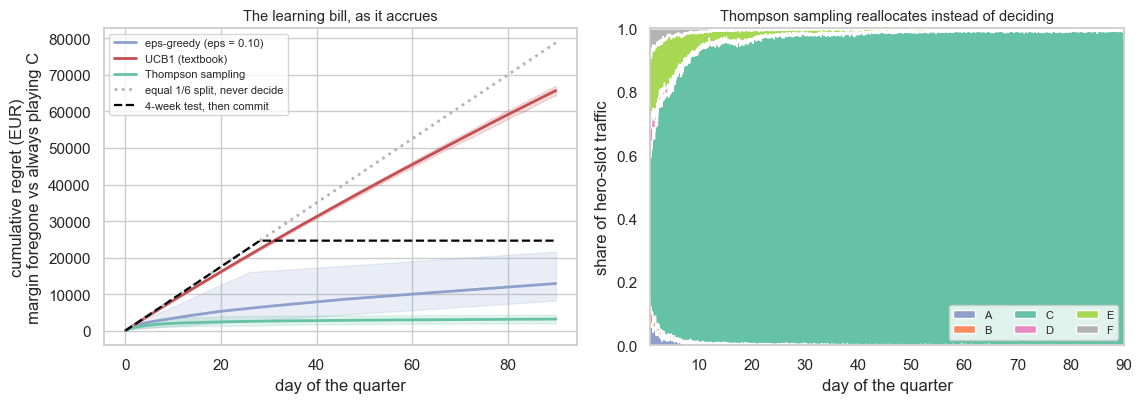

In [7]:
# FIG 2 -- the money curves; FIG 3 -- what Thompson sampling is doing to traffic
days = np.arange(1, B_QUARTER + 1) / BATCH_DAY
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))

colors = {"eps-greedy (eps = 0.10)": "#8da0cb", "UCB1 (textbook)": "#c44e52",
          "Thompson sampling": "#66c2a5"}
for name, r in runs.items():
    reg = r["regret"]
    axes[0].plot(days, reg.mean(0), lw=2, color=colors[name], label=name)
    axes[0].fill_between(days, np.percentile(reg, 10, axis=0),
                         np.percentile(reg, 90, axis=0), color=colors[name], alpha=0.18)
axes[0].plot(days, gap_uniform * days * SESSIONS_DAY, ls=":", color="#b3b3b3", lw=2,
             label="equal 1/6 split, never decide")
axes[0].plot(days, np.where(days <= TEST_DAYS, gap_uniform * days * SESSIONS_DAY, BASELINE),
             ls="--", color="black", lw=1.6, label="4-week test, then commit")
axes[0].set_xlabel("day of the quarter")
axes[0].set_ylabel("cumulative regret (EUR)\nmargin foregone vs always playing C")
axes[0].set_title("The learning bill, as it accrues", fontsize=10.5)
axes[0].legend(fontsize=8, loc="upper left")

ts_share = runs["Thompson sampling"]["share"]
axes[1].stackplot(days, ts_share.T, labels=list(OFFERS.index),
                  colors=["#8da0cb", "#fc8d62", "#66c2a5", "#e78ac3", "#a6d854", "#b3b3b3"])
axes[1].set_xlim(1, QUARTER_DAYS)
axes[1].set_ylim(0, 1)
axes[1].set_xlabel("day of the quarter")
axes[1].set_ylabel("share of hero-slot traffic")
axes[1].set_title("Thompson sampling reallocates instead of deciding", fontsize=10.5)
axes[1].legend(fontsize=8, loc="lower right", ncol=3)
plt.tight_layout()
plt.show()

The right panel is the picture to carry away. Nothing in Thompson sampling ever "declares a winner". The black dashed line in the left panel does that — it accrues regret at full speed for 28 days and then stops dead. Thompson's green curve instead **bends**: it is steep for the first few days, when the posterior is flat and traffic really is spread six ways, and nearly horizontal by day 20, when the posterior has concentrated. It never fully stops, because it never fully rules anything out — and that residual wobble is what will save it in §5b, when the winner stops winning.

The mechanism is worth stating precisely, because it is the whole reason Thompson sampling behaves so well: **the share of traffic an offer receives is the posterior probability that this offer is the best one.** Not a rule, a consequence. An offer that is plausibly best 3 % of the time gets 3 % of traffic — enough to keep learning about it, cheap enough that being wrong about it costs 3 % of the gap. Compare with ε-greedy, which gives every loser the same 1/60th of traffic whether it is nearly-best or hopeless.

### 🔬 What actually happens: UCB1's bonus does not know what a euro is

UCB1's exploration bonus $\sqrt{2 \ln t / n_a}$ is stated in **reward units**, and the theory that produces it assumes rewards live in $[0, 1]$. Our reward is `margin × Bernoulli`, so the honest rescaling is to divide by the largest possible payout, €41 — after which the *best* offer's mean reward is 0.902/41 = **0.022**, and the differences between offers are a fraction of a percent. The bonus, meanwhile, starts at 1.0 and decays like $1/\sqrt{n}$. It takes tens of thousands of sessions per arm before a signal that small can out-vote it, so UCB1 explores almost uniformly for most of the quarter.

The fix is not a different algorithm; it is telling the algorithm what a plausible reward looks like. Rescale by the **realistic** ceiling on euros-per-session (€1.50, comfortably above every offer) instead of the theoretical one:

In [8]:
runs["UCB1 (scaled to EUR 1.50)"] = run_bandit(ucb1, B_QUARTER, seed=4, scale=1.50)
for name in ("UCB1 (textbook)", "UCB1 (scaled to EUR 1.50)"):
    fin = runs[name]["regret"][:, -1]
    lo, hi = np.percentile(fin, [10, 90])
    print(f"{name:<28}{fin.mean():>12,.0f} EUR   10-90 % band {lo:>9,.0f} - {hi:>9,.0f}")

UCB1 (textbook)                   65,685 EUR   10-90 % band    64,297 -    66,986
UCB1 (scaled to EUR 1.50)          8,794 EUR   10-90 % band       774 -    54,289


**€65,685 → €8,794** from changing one constant. Two lessons, and the second is the one that survives the notebook:

1. UCB-family algorithms have a **scale parameter you are responsible for**, even when the formula hides it. Textbook UCB1 assumes it away; UCB-tuned and UCB-V estimate it from the observed variance, which is what you should reach for in practice.
2. Look at the 10–90 % band on the rescaled version: **€774 to €54,289**. The *mean* now beats ε-greedy, but the spread is enormous — because UCB1 is deterministic within a batch, a run that gets unlucky early commits 200 sessions at a time to the wrong offer and needs a long time to climb back. Thompson sampling's band is €2,049–€4,420. When a policy runs on live revenue, **the width of that band is a risk number the finance director is entitled to see**, and a lower mean with a fat tail is not obviously the better deal.

---

### ✋ Quick exercise (~2 min) — one Thompson draw, by hand

Ten days into the quarter the posteriors look like this (Beta parameters, from `1 + conversions` and `1 + misses`):

| offer | α | β | margin |
|---|---|---|---|
| A | 39 | 1163 | €18.00 |
| B | 62 | 1440 | €14.00 |
| C | 10 | 392 | €41.00 |
| D | 45 | 1157 | €16.50 |
| E | 14 | 488 | €29.00 |
| F | 31 | 971 | €21.00 |

Take **one** draw from each posterior with `np.random.default_rng(2)`, then answer: which offer would a *conversion-rate* bandit show this session, and which offer does the **euro** bandit show?

In [9]:
# ✍️ Your turn 👇
alpha = np.array([39, 62, 10, 45, 14, 31], dtype=float)
beta_ = np.array([1163, 1440, 392, 1157, 488, 971], dtype=float)
# draw = np.random.default_rng(2).beta(alpha, beta_)
# the click bandit picks argmax(draw); the euro bandit picks argmax(draw * MARGIN)

<details>
<summary>✅ <b>Solution</b></summary>

```python
alpha = np.array([39, 62, 10, 45, 14, 31], dtype=float)
beta_ = np.array([1163, 1440, 392, 1157, 488, 971], dtype=float)
draw = np.random.default_rng(2).beta(alpha, beta_)
tbl = pd.DataFrame({"sampled cvr": draw, "margin": MARGIN,
                    "sampled EUR/session": draw * MARGIN}, index=OFFERS.index)
print(tbl.round(4).to_string())
print(f"\nclick bandit shows : {OFFERS.index[draw.argmax()]}")
print(f"euro  bandit shows : {OFFERS.index[(draw * MARGIN).argmax()]}")
```

This draw gives B a sampled rate of **5.11 %** and C a sampled rate of **2.50 %** — so a click bandit shows **B**. Priced, those same samples are **€0.716** and **€1.027**, so the euro bandit shows **C**. One `* MARGIN` separates the two systems, and over a quarter it is worth six figures.

Two details worth noticing while you have the numbers in front of you. C's posterior is the *widest* of the six (α = 10 against α = 62 for B) because it has had the least traffic — and that width is precisely why it still gets drawn high often enough to be chosen. And E's sample lands at €0.904, a whisker under C: at this point in the quarter the bandit genuinely cannot separate the top two, so it keeps splitting between them. That is not indecision, it is the correct amount of decision for the evidence available.
</details>

## 3. The bill for adaptivity: your estimates are now biased

The bandit saved €20,743 a quarter. Time to read the small print.

After the quarter ends, the merchandising director asks the only question they were ever going to ask: *"Good — so how much better is C than what we were running?"* You have 360,000 sessions of data. You compute each offer's conversion rate the obvious way, conversions over sessions, and you put the lift in the slide.

That number is wrong, and it is wrong in a *direction*.

Here is why, and it takes one sentence: **how much data an offer has depends on how well it happened to do**. An offer that converted unluckily in its first few hundred sessions gets its posterior pushed down, gets less traffic, and therefore gets fewer chances to recover — so its sample mean is *frozen at the unlucky value*. An offer that got lucky is sampled more and regresses to its truth. The sampling rule and the outcome are entangled, which is exactly the thing randomization was invented to prevent. A2 protected the estimate by fixing the allocation in advance; the bandit un-fixes it.

### 🔮 Predict the output

The next cell runs Thompson sampling for four weeks (112,000 sessions — the *same volume* as today's equal-split test), 300 times, and compares each offer's naive sample conversion rate against its true rate. Before you run it, commit to answers:

1. Will the naive rates come out **too high**, **too low**, or unbiased on average?
2. Which of the six offers will be **most** wrong, and why?
3. The lift the director gets told — winner versus incumbent F — will it be **overstated** or **understated**?

In [10]:
BIAS_REPS = 300
ts_bias = run_bandit(thompson, B_TEST, seed=7, reps=BIAS_REPS)
pulls_b, wins_b = ts_bias["pulls"], ts_bias["wins"]
phat_b = wins_b / np.maximum(pulls_b, 1)

# the same data volume, allocated the way A2 would have allocated it
rng_e = np.random.default_rng(8)
n_each = B_TEST * BATCH // K
phat_e = rng_e.binomial(n_each, np.broadcast_to(P_TRUE, (BIAS_REPS, K))) / n_each

bias = pd.DataFrame({
    "true cvr %": P_TRUE * 100,
    "bandit sessions": pulls_b.mean(0),
    "bandit cvr %": phat_b.mean(0) * 100,
    "bandit bias pp": (phat_b.mean(0) - P_TRUE) * 100,
    "equal-split bias pp": (phat_e.mean(0) - P_TRUE) * 100,
}, index=OFFERS.index)
print(bias.round(3).to_string())

lift_b = (phat_b * MARGIN).max(1) / (phat_b[:, 5] * MARGIN[5]) - 1
lift_e = (phat_e * MARGIN).max(1) / (phat_e[:, 5] * MARGIN[5]) - 1
lift_true = VALUE[BEST] / VALUE[5] - 1
print(f"\nreported lift of the winner over incumbent F, EUR per session:")
print(f"  from the bandit's own data : {lift_b.mean():+.1%}")
print(f"  from an equal-split test   : {lift_e.mean():+.1%}")
print(f"  the truth                  : {lift_true:+.1%}")

   true cvr %  bandit sessions  bandit cvr %  bandit bias pp  equal-split bias pp
A         3.4         1557.347         3.139          -0.261                0.004
B         4.1          961.637         3.684          -0.416                0.001
C         2.2        98709.520         2.200           0.000                0.000
D         3.8         1507.943         3.450          -0.350                0.007
E         2.6         7248.787         2.448          -0.152                0.008
F         3.0         2014.767         2.799          -0.201               -0.007

reported lift of the winner over incumbent F, EUR per session:
  from the bandit's own data : +63.8%
  from an equal-split test   : +43.7%
  the truth                  : +43.2%


Every one of the six offers comes out **too low** — the bias column has no positive entries — and the size of the error tracks how little traffic the offer got. Offer **B**, the one the bandit abandons fastest because its thin margin makes it a poor euro bet, is understated by **0.42 pp**: a true 4.1 % reported as **3.68 %**, a **10 %** relative error, from 112,000 clean sessions of the company's own live traffic. The equal-split column, run on the same volume, is zero to three decimal places.

The winner itself is *fine*: offer C received **98,710** of the 112,000 sessions, so its mean is essentially exact. That is the trap. The estimate that survives is the one nobody needed, and the estimates that get destroyed are the **comparisons** — which is the only form in which anybody ever quotes an experiment.

**The lift the director gets told is +63.8 %. The truth is +43.2 %.** The bandit's own data overstates its own achievement by half, and the equal-split test run on identical volume reports **+43.7 %**, right on the money. Nothing in the bandit's output flags this. There is no p-value to be suspicious of, no diagnostic that goes red; the arithmetic is correct and the answer is fiction.

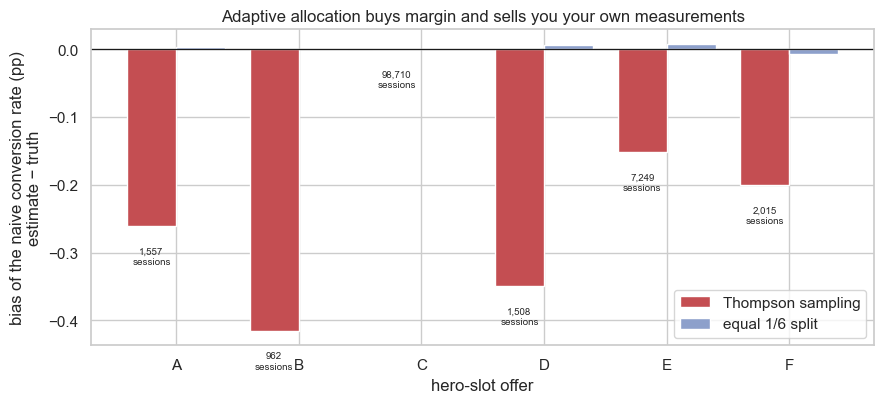

after only 2 days: the bandit picks C 76% of the time, and reports its chosen offer at EUR 0.889/session against that offer's true EUR 0.859 (+3.5%)


In [11]:
# FIG 4 -- the same 112,000 sessions, allocated two ways
fig, ax = plt.subplots(figsize=(9, 4.2))
x = np.arange(K)
ax.bar(x - 0.2, bias["bandit bias pp"], 0.4, color="#c44e52", label="Thompson sampling")
ax.bar(x + 0.2, bias["equal-split bias pp"], 0.4, color="#8da0cb", label="equal 1/6 split")
for i in range(K):
    ax.text(i - 0.2, bias["bandit bias pp"].iloc[i] - 0.03,
            f"{pulls_b.mean(0)[i]:,.0f}\nsessions", ha="center", va="top", fontsize=7)
ax.axhline(0, color="k", lw=0.9)
ax.set_xticks(x, OFFERS.index)
ax.set_xlabel("hero-slot offer")
ax.set_ylabel("bias of the naive conversion rate (pp)\nestimate − truth")
ax.set_title("Adaptive allocation buys margin and sells you your own measurements")
ax.legend()
plt.tight_layout()
plt.show()

# and the fixed-horizon cousin, for comparison: a 3-day bandit, where the WINNER
# is not yet resolved and selection optimism shows up on top of the bias above
short = run_bandit(thompson, 2 * BATCH_DAY, seed=11, reps=400)
ph_s = short["wins"] / np.maximum(short["pulls"], 1)
sel = (ph_s * MARGIN).argmax(1)
print(f"after only 2 days: the bandit picks C {np.mean(sel == BEST):.0%} of the time, and "
      f"reports its chosen offer at EUR {(ph_s * MARGIN).max(1).mean():.3f}/session "
      f"against that offer's true EUR {VALUE[sel].mean():.3f} "
      f"({(ph_s * MARGIN).max(1).mean() / VALUE[sel].mean() - 1:+.1%})")

The two-day run adds the second half of the disease. Early on the bandit has only crowned C **76 %** of the time, and whichever offer is *currently* winning is disproportionately likely to be winning because of luck — so the value it reports for its own choice, **€0.889**, runs **+3.5 %** above that offer's actual €0.859. You have met this before under a different name: it is **A2 §7's winner's curse** — selecting on a noisy maximum inflates the maximum — and the only difference is that A2's version happens once, at the end, on a fixed sample, while the bandit's version happens continuously and *feeds back into the allocation*.

Both effects push the same way. Losers are understated because they were abandoned; winners are overstated because they were selected. The reported gap between them is the sum of two biases pointing in opposite directions.

> ⚠️ **The rule, and it is the reason this notebook sits in Module 7.**
> **Bandits optimise. Experiments estimate.** Choose by the deliverable, not by the fashion:
> - If the deliverable is a **decision** — which offer runs tomorrow, which of five subject lines, which ranking model serves the next request — adapt. The number is disposable; the allocation is the product.
> - If the deliverable is a **number someone will reuse** — a business case, a coefficient that feeds a pricing model, a lift you will publish, a benchmark next year's team will be measured against — randomize. A2's four weeks are not overhead; they are the cost of an estimate you are allowed to put your name on.
>
> And when you need both, buy both: run the bandit on 90 % of traffic and hold **10 % in a permanently randomized slice**. The bandit earns the money, the holdout writes the number. That is the same standing order A4 §7 ended on, and it costs about what §4's exploration floor costs — priced in the next section.

---

### ✋ Quick exercise (~2 min) — read the allocation

Using `runs["Thompson sampling"]["share"]` (one row per 200-session batch, one column per offer) and the `bias` table above, answer three questions with code:

1. Collapse `share` to **daily** averages. On which day does offer C first take more than half of hero-slot traffic, and on which day does it pass 90 %?
2. What share does C already hold on **day 1**, before any real evidence exists — and why is it the largest of the six on day one?
3. Offer **E** got 7,249 sessions in the four-week run and offer **B** got 962. Which of the two has the smaller bias, and does that ordering make sense?

In [12]:
# ✍️ Your turn 👇
share_ts = runs["Thompson sampling"]["share"]                       # (1800 batches, 6)
daily = share_ts.reshape(QUARTER_DAYS, BATCH_DAY, K).mean(axis=1)   # (90 days, 6)
# 1. np.argmax(daily[:, BEST] > 0.5) + 1   ... and the same with > 0.9
# 2. daily[0] -- the day-one split
# 3. compare bias.loc["E", "bandit bias pp"] and bias.loc["B", "bandit bias pp"]

<details>
<summary>✅ <b>Solution</b></summary>

```python
share_ts = runs["Thompson sampling"]["share"]
daily = share_ts.reshape(QUARTER_DAYS, BATCH_DAY, K).mean(axis=1)
print(f"1. C passes 50 % of traffic on day {int(np.argmax(daily[:, BEST] > 0.5)) + 1}, "
      f"and 90 % on day {int(np.argmax(daily[:, BEST] > 0.9)) + 1}")
print("2. day-one split: "
      + "  ".join(f"{o} {v:.0%}" for o, v in zip(OFFERS.index, daily[0])))
print(f"3. E: {bias.loc['E', 'bandit sessions']:,.0f} sessions, "
      f"bias {bias.loc['E', 'bandit bias pp']:+.2f} pp")
print(f"   B: {bias.loc['B', 'bandit sessions']:,.0f} sessions, "
      f"bias {bias.loc['B', 'bandit bias pp']:+.2f} pp")
```

**Day 2 and day 10.** The decision is effectively made inside the first 48 hours, which is why the regret curve is already bending before the equal-split test has finished its first week — and it is exactly why §3's bias is so severe: four of the six offers never reach 2,100 sessions across the entire four weeks, while C takes 98,710.

**On day one C already holds 40 %**, and that is worth understanding rather than skipping. The flat `Beta(1, 1)` prior is uninformative about *conversion rates* — but the margins are known constants, so a sampled rate of 3 % is worth €1.23 on offer C and €0.42 on offer B before a single session is served. Thompson sampling is optimistic about high-margin arms by construction. Usually that is a feature (it explores where the upside is); occasionally it is a trap, and it is the mechanism §4's stale prior weaponises.

The third answer is the section's mechanism in miniature: **E has seven times more sessions than B and a bias less than half as large** (−0.15 pp vs −0.42 pp). Bias here is not about how good an offer is, it is about how much data survived the selection — E stays in contention for the top spot far longer, so it keeps being sampled, so its mean keeps being corrected. B is written off early and stays written off. *The offers you are most wrong about are the ones you decided about fastest.*
</details>

## 4. Contextual bandits — the bridge back to A4

So far every session has been treated as interchangeable. They are not. A first-time visitor on a phone with an empty basket and a returning buyer at a desk with €300 of toner in the cart are different businesses, and the hero slot can tell them apart *before* choosing: the session already carries `returning`, `mobile` and `basket > €150`. Eight segments, six offers.

A **contextual bandit** is the obvious upgrade: run a separate Thompson sampler per segment. (The industry's other standard answer, **LinUCB**, fits a linear model of reward on context features and adds a confidence bonus in that model's parameter space — the right choice when contexts are continuous or too numerous to bucket. With eight discrete segments and plenty of traffic, per-segment sampling is simpler and strictly better specified.)

This is also where the thread ties back to **A4**. Both notebooks are answering *who reacts to what*:

- **A4 learns it offline.** Randomize, wait, then fit a T-learner on the completed experiment and read out a treatment rule. The estimate is clean, the machinery is heavy, and the answer arrives one quarter late.
- **A contextual bandit learns it while serving.** No completed experiment, no model handover, the rule updates every 200 sessions — and, per §3, no trustworthy estimate of anything at the end.

They are the same question with the estimate/decision trade-off pointing in opposite directions. The hybrid that industry actually runs uses both: **warm-start the bandit's priors from the offline model**, so day one already behaves like day thirty. Which invites a specific and expensive failure, demonstrated below.

In [13]:
import itertools

SEGMENTS = list(itertools.product([0, 1], [0, 1], [0, 1]))     # returning, mobile, big basket
SEG_LABEL = [f"{'returning' if r else 'new':>9}/{'mobile' if m else 'desktop':>7}/"
             f"{'big' if b else 'small':>5}" for r, m, b in SEGMENTS]
SEG_SHARE = np.array([0.10, 0.05, 0.20, 0.05, 0.12, 0.13, 0.20, 0.15])
SEG_N = (SEG_SHARE * BATCH).astype(int)                        # sessions per batch, per segment

# Segment-level response: an offer's pull depends on who is looking at it.
mult = np.ones((8, K))
for i, (ret, mob, big) in enumerate(SEGMENTS):
    mult[i, 0] = 0.68 if ret else 1.28                                   # A: FIRST-order discount
    mult[i, 1] = (1.20 if mob else 0.86) * (0.90 if big else 1.10)       # B: free delivery
    mult[i, 2] = (1.30 if ret else 0.66) * (1.28 if big else 0.84)       # C: bundle
    mult[i, 3] = 1.45 if big else 0.80                                   # D: EUR 5 over EUR 50
    mult[i, 4] = (1.24 if ret else 0.76) * (0.90 if mob else 1.12)       # E: chairs
P_SEG = P_TRUE * mult
P_SEG = P_SEG * (P_TRUE / (SEG_SHARE @ P_SEG))     # keep each offer's overall rate at P_TRUE
V_SEG = P_SEG * MARGIN

seg_tbl = pd.DataFrame(V_SEG, index=SEG_LABEL, columns=OFFERS.index).round(3)
seg_tbl.insert(0, "share", SEG_SHARE)
seg_tbl["best"] = [OFFERS.index[j] for j in V_SEG.argmax(1)]
print("expected EUR of margin per session, by segment and offer\n")
print(seg_tbl.to_string())

v_global = SEG_SHARE @ V_SEG
oracle_ctx = (SEG_SHARE * V_SEG.max(1)).sum()
print(f"\nbest single offer for everyone : {OFFERS.index[v_global.argmax()]} "
      f"at EUR {v_global.max():.4f}/session")
print(f"best offer per segment         : EUR {oracle_ctx:.4f}/session "
      f"({oracle_ctx / v_global.max() - 1:+.1%})")
print(f"personalisation is worth        EUR {(oracle_ctx - v_global.max()) * SESSIONS_Q:,.0f} "
      f"per quarter, at most")

expected EUR of margin per session, by segment and offer

                         share      A      B      C      D      E     F best
      new/desktop/small   0.10  0.851  0.498  0.469  0.479  0.619  0.63    A
      new/desktop/  big   0.05  0.851  0.407  0.715  0.868  0.619  0.63    D
      new/ mobile/small   0.20  0.851  0.694  0.469  0.479  0.498  0.63    A
      new/ mobile/  big   0.05  0.851  0.568  0.715  0.868  0.498  0.63    D
returning/desktop/small   0.12  0.452  0.498  0.924  0.479  1.010  0.63    E
returning/desktop/  big   0.13  0.452  0.407  1.408  0.868  1.010  0.63    C
returning/ mobile/small   0.20  0.452  0.694  0.924  0.479  0.812  0.63    C
returning/ mobile/  big   0.15  0.452  0.568  1.408  0.868  0.812  0.63    C

best single offer for everyone : C at EUR 0.9020/session
best offer per segment         : EUR 1.0425/session (+15.6%)
personalisation is worth        EUR 50,568 per quarter, at most


In [14]:
def run_contextual(mode, n_batches, seed, reps=25, floor=0.0, prior=None):
    """`mode`: 'equal' (1/6 to everyone), 'global' (one bandit), 'segment' (eight)."""
    rng = np.random.default_rng(seed)
    shape = (reps, 8, K) if mode == "segment" else (reps, K)
    pulls, wins = np.zeros(shape), np.zeros(shape)
    pa, pb = (1.0, 1.0) if prior is None else prior
    regret = np.empty((reps, n_batches))
    best_batch = (SEG_N * V_SEG.max(1)).sum()
    for b in range(n_batches):
        if mode == "equal":
            probs = np.full((reps, 8, K), 1 / K)
        else:
            a = np.broadcast_to((pa + wins)[..., None, :], shape[:-1] + (32, K))
            bt = np.broadcast_to((pb + pulls - wins)[..., None, :], shape[:-1] + (32, K))
            hit = (rng.beta(a, bt) * MARGIN).argmax(-1)
            pr = np.stack([(hit == j).mean(-1) for j in range(K)], axis=-1)
            pr = (1 - floor) * pr + floor / K
            probs = pr if mode == "segment" else np.repeat(pr[:, None, :], 8, axis=1)
        n = rng.multinomial(np.broadcast_to(SEG_N, (reps, 8)), probs)
        c = rng.binomial(n, P_SEG)
        if mode == "segment":
            pulls, wins = pulls + n, wins + c
        else:
            pulls, wins = pulls + n.sum(1), wins + c.sum(1)
        regret[:, b] = best_batch - (n * V_SEG).sum((1, 2))
    return regret.cumsum(1)


ctx = {name: run_contextual(name, B_QUARTER, seed=3)
       for name in ("equal", "global", "segment")}
labels = {"equal": "equal 1/6 split (no learning)",
          "global": "one context-free Thompson bandit",
          "segment": "eight per-segment Thompson bandits"}
print(f"{'policy':<36}{'EUR regret / quarter':>22}")
for name, r in ctx.items():
    print(f"{labels[name]:<36}{r[:, -1].mean():>22,.0f}")
CTX_GAIN = ctx["global"][:, -1].mean() - ctx["segment"][:, -1].mean()
print(f"\ncontextual over context-free: EUR {CTX_GAIN:,.0f} per quarter "
      f"(EUR {CTX_GAIN * 4:,.0f} a year)")

policy                                EUR regret / quarter
equal 1/6 split (no learning)                      129,331
one context-free Thompson bandit                    53,790
eight per-segment Thompson bandits                  13,832

contextual over context-free: EUR 39,958 per quarter (EUR 159,831 a year)


Regret is now measured against a harder oracle — the best offer *for each segment* — so all three numbers rise. The ranking is what matters: **€129,331 → €53,790 → €13,832**. Personalising the hero slot is worth **€39,958 a quarter, €159,831 a year**, and that is on top of everything §2 bought. It is also, notably, more than the entire learning bill the notebook set out to reduce: choosing *what to show whom* dominates choosing *how fast to learn*.

Look at the segment table to see why. Four different offers win in different segments — **A** for new visitors with small baskets, **D** once a new visitor's basket clears €50 (the voucher becomes free money), **C** for returning buyers, **E** for returning desktop shoppers with small baskets. The incumbent **F** is the best offer in *no segment at all*, which is a fair summary of what a year of one-size-fits-all merchandising does.

Now the warm start, and the failure it invites.

In [15]:
rng_p = np.random.default_rng(101)
p_good = (P_SEG * (1 + rng_p.normal(0, 0.10, P_SEG.shape))).clip(0.002, 0.4)   # a decent offline model
p_stale = np.tile([0.020, 0.022, 0.010, 0.020, 0.016, 0.050], (8, 1))          # last year's model: F is king

def prior_from(p, n0):
    """Turn a predicted rate into Beta pseudo-counts worth `n0` sessions per offer."""
    return 1 + n0 * p, 1 + n0 * (1 - p)

setups = [
    ("cold start (flat priors)",                      None,                 0.00),
    ("warm start from a GOOD offline model",          prior_from(p_good, 3000),  0.00),
    ("warm start from a STALE offline model",         prior_from(p_stale, 3000), 0.00),
    ("  ... + 10 % forced-exploration floor",         prior_from(p_stale, 3000), 0.10),
    ("  ... + floor AND prior capped at 300 sessions", prior_from(p_stale, 300), 0.10),
    ("cold start + 10 % floor (the insurance)",       None,                 0.10),
]
print(f"{'per-segment Thompson sampling':<50}{'EUR regret / quarter':>22}")
warm = {}
for label, prior, floor in setups:
    r = run_contextual("segment", B_QUARTER, seed=3, floor=floor, prior=prior)
    warm[label] = r[:, -1].mean()
    print(f"{label:<50}{warm[label]:>22,.0f}")

per-segment Thompson sampling                       EUR regret / quarter


cold start (flat priors)                                          13,832


warm start from a GOOD offline model                               2,639


warm start from a STALE offline model                            138,720


  ... + 10 % forced-exploration floor                             97,607


  ... + floor AND prior capped at 300 sessions                    25,401


cold start + 10 % floor (the insurance)                           24,184


The good warm start is exactly what the hybrid promises: **€13,832 → €2,639**, a further €11,193 a quarter, because A4's offline model already knows which segments like bundles and the bandit does not have to rediscover it on live traffic.

The stale one is a catastrophe: **€138,720** — ten times the cold-start bandit, and *worse than not personalising at all* (the equal split cost €129,331). A prior worth 3,000 pseudo-sessions per offer per segment is a claim, asserted with the authority of 24,000 observations that never happened, and probability matching believes it: offer F looks best everywhere, so F gets the traffic, so the data that would refute F never arrives. The bandit has locked itself out of its own correction mechanism.

**The floor helps, and it is not enough.** Forcing 10 % of traffic to be split uniformly regardless of the posterior takes €138,720 down to €97,607 — it bounds the *rate* at which a wrong belief can bleed you, because every offer keeps receiving at least 1.7 % of sessions and therefore keeps generating evidence. But it cannot un-assert an over-confident prior. Only capping the prior does that: discount the offline model to **300** pseudo-sessions and the same stale model costs **€25,401**, statistically indistinguishable from a cold start with the same floor (€24,184).

> 🧭 **You have seen this exact idea before, in a completely different suit.** **A3 §6** deliberately approved a random sample of applications the scorecard wanted to decline, because a policy that only ever observes its own approvals can never learn it is wrong. The exploration floor is that, at 200-session resolution: *a permanent, budgeted purchase of information about the options you have decided against.* A3 priced its budget in defaults; here the price is **€24,184 − €13,832 = €10,352 a quarter** — the cold-start bandit's regret rises by that much when you insist on the floor. That is the insurance premium. §5b is the claim it pays out on.

## 5. When a bandit is the wrong tool

Everything so far argues for adaptivity. This section is the other half of the argument, and it is the half that keeps you employed — because "we should use a bandit" is the kind of proposal that sounds sophisticated in a steering committee and is wrong roughly half the time. Four conditions break it. Three of them we can price.

**(a) Delayed rewards.** A bandit's advantage comes from the *loop*: show, observe, reallocate. If the reward arrives 30 days after the session — a subscription that converts on the free-trial anniversary, a B2B quote that becomes an order next month, a churn outcome — then the bandit spends most of the quarter reallocating on information about a version of the world that is a month old.

In [16]:
def run_delayed(delay_days, n_batches=B_QUARTER, seed=21, reps=40):
    """Thompson sampling where a session's conversion is only observed `delay_days` later."""
    rng = np.random.default_rng(seed)
    pulls, wins = np.zeros((reps, K)), np.zeros((reps, K))
    regret = np.zeros(reps)
    pipeline = []                                    # feedback still in flight
    lag = delay_days * BATCH_DAY
    for b in range(n_batches):
        probs = thompson(pulls, wins, b, rng, MARGIN)
        n = rng.multinomial(BATCH, probs)
        c = rng.binomial(n, P_TRUE)
        regret += BATCH * VALUE[BEST] - (n * VALUE).sum(1)
        pipeline.append((n, c))
        if len(pipeline) > lag:                      # ... arrives `lag` batches later
            n0, c0 = pipeline.pop(0)
            pulls += n0
            wins += c0
    return regret

print(f"{'conversion is measured':<26}{'TS regret / quarter':>21}"
      f"{'advantage over the 4-week test':>32}")
delay_curve = {}
for d in (0, 1, 7, 30):
    r = run_delayed(d)
    delay_curve[d] = r.mean()
    print(f"{f'{d} days after the session':<26}{r.mean():>21,.0f}{BASELINE - r.mean():>32,.0f}")
print(f"\n30-day feedback destroys EUR {(BASELINE - delay_curve[0]) - (BASELINE - delay_curve[30]):,.0f} "
      f"of the bandit's quarterly advantage.")

conversion is measured      TS regret / quarter  advantage over the 4-week test


0 days after the session                  3,198                          21,458


1 days after the session                  4,025                          20,631


7 days after the session                  7,443                          17,213


30 days after the session                16,617                           8,039

30-day feedback destroys EUR 13,419 of the bandit's quarterly advantage.


Same-session feedback: the bandit is worth **€21,458** a quarter over the fixed test. Thirty-day feedback: **€8,039** — it has given up **€13,419**, roughly two thirds of its edge, and it has done so while remaining considerably more complicated to build, monitor and explain than a spreadsheet with six rows.

Be careful about the conclusion, though, because the honest version is narrower than the slogan. Delayed feedback hurts *everyone* — the fixed 4-week test also cannot read out until 30 days after its last session, so its true cycle time is eight weeks, not four. The precise claim is about **cadence**: adaptivity is only worth its complexity when the feedback loop closes faster than the decision cadence. If it does not, use the delay productively — bandit on a fast **surrogate** you can measure in-session (add-to-cart; A2 §2's proxy-metric trade-off applies in full, including its warning that proxies move without the goal moving), and keep the slow metric as a periodic randomized check.

**(b) Non-stationarity — a winner that stops winning.** Creative fatigue is real: the bundle that everyone wants in week one is wallpaper by week eight. Suppose C's conversion rate decays by 55 % between day 45 and day 60. The best offer changes. A standard bandit, having spent six weeks accumulating evidence that C is best, is now maximally confident about something that has stopped being true.

policy                                   days 1-45   days 46-90    quarter


standard Thompson (never forgets)            2,671       34,229     36,901


discounted Thompson (gamma = 0.995)          7,242       11,072     18,313

after the fatigue, offer values are: {'A': np.float64(0.612), 'B': np.float64(0.574), 'C': np.float64(0.406), 'D': np.float64(0.627), 'E': np.float64(0.754), 'F': np.float64(0.63)}
cost of the stale arm, days 46-90: EUR 23,158


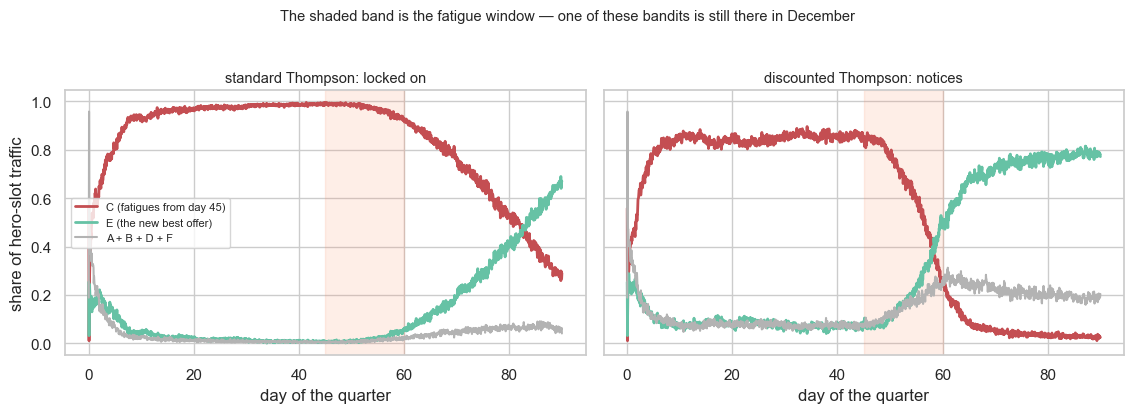

In [17]:
def p_on_day(day, fatigue=0.55, start=45, over=15):
    """Offer C's rate decays to (1 - fatigue) of itself between day `start` and `start+over`."""
    p = P_TRUE.copy()
    p[BEST] = P_TRUE[BEST] * (1 - fatigue * np.clip((day - start) / over, 0, 1))
    return p


def run_drifting(gamma=1.0, n_batches=B_QUARTER, seed=31, reps=40):
    """`gamma` < 1 discounts old evidence every batch -- a bandit that forgets."""
    rng = np.random.default_rng(seed)
    pulls, wins = np.zeros((reps, K)), np.zeros((reps, K))
    regret = np.empty((reps, n_batches))
    share = np.empty((n_batches, K))
    for b in range(n_batches):
        p = p_on_day(b / BATCH_DAY)
        value = p * MARGIN
        probs = thompson(pulls, wins, b, rng, MARGIN)
        n = rng.multinomial(BATCH, probs)
        c = rng.binomial(n, p)
        pulls, wins = gamma * pulls + n, gamma * wins + c
        regret[:, b] = BATCH * value.max() - (n * value).sum(1)
        share[b] = n.mean(0) / BATCH
    return regret.cumsum(1), share


drift = {}
print(f"{'policy':<38}{'days 1-45':>12}{'days 46-90':>13}{'quarter':>11}")
for gamma, label in [(1.0, "standard Thompson (never forgets)"),
                     (0.995, "discounted Thompson (gamma = 0.995)")]:
    reg, sh = run_drifting(gamma)
    drift[gamma] = (reg, sh)
    cut = reg[:, 45 * BATCH_DAY - 1].mean()
    print(f"{label:<38}{cut:>12,.0f}{reg[:, -1].mean() - cut:>13,.0f}{reg[:, -1].mean():>11,.0f}")
print(f"\nafter the fatigue, offer values are: "
      f"{dict(zip(OFFERS.index, (p_on_day(90) * MARGIN).round(3)))}")
STALE_COST = ((drift[1.0][0][:, -1] - drift[1.0][0][:, 45 * BATCH_DAY - 1]).mean()
              - (drift[0.995][0][:, -1] - drift[0.995][0][:, 45 * BATCH_DAY - 1]).mean())
print(f"cost of the stale arm, days 46-90: EUR {STALE_COST:,.0f}")

# FIG 5 -- who gets the traffic, before and after the winner stops winning
days = np.arange(1, B_QUARTER + 1) / BATCH_DAY
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4), sharey=True)
for ax, (gamma, title) in zip(axes, [(1.0, "standard Thompson: locked on"),
                                     (0.995, "discounted Thompson: notices")]):
    sh = drift[gamma][1]
    ax.plot(days, sh[:, BEST], color="#c44e52", lw=2, label="C (fatigues from day 45)")
    ax.plot(days, sh[:, 4], color="#66c2a5", lw=2, label="E (the new best offer)")
    ax.plot(days, sh[:, [0, 1, 3, 5]].sum(1), color="#b3b3b3", lw=1.5, label="A + B + D + F")
    ax.axvspan(45, 60, color="#fc8d62", alpha=0.15)
    ax.set_xlabel("day of the quarter")
    ax.set_title(title, fontsize=10.5)
axes[0].set_ylabel("share of hero-slot traffic")
axes[0].legend(fontsize=8, loc="center left")
plt.suptitle("The shaded band is the fatigue window — one of these bandits is still there in December",
             fontsize=10.5, y=1.03)
plt.tight_layout()
plt.show()

The left panel is what a locked-on bandit looks like: C holds 95 %+ of traffic through the fatigue window and is *still* holding it on day 90, because the 45 days of evidence it accumulated while C was genuinely best outvote everything the last month has said. Regret in the second half of the quarter: **€34,229**. The right panel forgets on a 10-day timescale ($\gamma = 0.995$, so evidence loses half its weight every ~139 batches) and hands the slot over to E within a fortnight: **€11,072**.

**The stale arm costs €23,158 in the six weeks before a forgetful bandit notices** — which is roughly one quarter's entire learning bill, spent on being confidently wrong.

Forgetting is not free, and the table shows the premium honestly: over days 1–45, when nothing was changing, the discounted bandit paid **€7,242** against the standard bandit's **€2,671**. It keeps re-litigating a settled question. That is the trade in one line — **€4,571 of insurance premium against €23,158 of claim** — and like every insurance decision it turns on how often you expect the world to move. Creative fatigue, seasonality, a competitor's campaign, a supply problem that makes your best bundle undeliverable: on a homepage, the answer is "several times a year", and the premium is obviously worth paying. On a checkout-button colour, it is not.

**(c) Too few decisions.** Every regret guarantee in the literature is asymptotic in the number of decisions. If the homepage is re-decided three times a year because that is how often the brand team ships creative, the asymptotics never arrive.

In [18]:
YEAR = 365 * SESSIONS_DAY
equal_year = (VALUE[BEST] - VALUE.mean()) * YEAR
print(f"an equal 1/6 split costs EUR {equal_year:,.0f} a year; a single 4-week test, "
      f"then commit for the rest of the year, costs EUR {BASELINE:,.0f}\n")
print(f"{'re-decisions per year':>22}{'sessions per decision':>23}"
      f"{'TS regret / year':>19}{'% of the equal split':>22}")
for n_rounds in (3, 12, 52, 365, 7300):
    block = YEAR // n_rounds
    r = run_bandit(thompson, n_rounds, seed=41, reps=200, batch=block)
    reg = r["regret"][:, -1].mean()
    print(f"{n_rounds:>22,}{block:>23,}{reg:>19,.0f}{reg / equal_year:>21.0%}")

an equal 1/6 split costs EUR 319,497 a year; a single 4-week test, then commit for the rest of the year, costs EUR 24,656

 re-decisions per year  sessions per decision   TS regret / year  % of the equal split
                     3                486,666            166,203                  52%
                    12                121,666             41,698                  13%
                    52                 28,076             11,599                   4%


                   365                  4,000              4,678                   1%


                 7,300                    200              4,087                   1%


At **3 decisions a year the bandit costs €166,203** — it recovers about half of the equal-split bill, which sounds fine until you notice the comparison it actually loses: a **single 4-week equal-split test at the start of the year costs €24,656 and then commits**, so the experiment beats the bandit by **€141,547**. The reason is structural and worth internalising: the bandit's first decision covers 486,666 sessions and is made from an empty posterior, i.e. at random. When the block is that big, "adaptive" means "one uninformed guess, then two corrections".

The curve turns somewhere around **weekly** re-decisions (52 a year, 4 % of the equal-split bill) and is flat from **daily** onwards — which is the practical charter for a bandit: *you need hundreds of decision points inside the horizon you care about*. It is also good news for §5a's cousin problem, because it means daily batch updates cost essentially nothing versus continuous ones (🧠 Stretch A).

**(d) The organisational cost, which has no formula.** Somebody in brand will ask why the homepage looked different to two colleagues in the same meeting. Somebody in finance will ask why last Tuesday's traffic split does not reconcile with the plan. The creative agency will ask which version "won" and will not accept "none of them, permanently, in proportion to posterior probability" as an answer. A 4-week equal split is legible to every one of those people; a bandit is legible to you. Budget for a dashboard that shows the current split, a written rule for when a human may override it, and a monthly one-pager in the language of the fixed test — *"if we had run a classic A/B/n test this month, here is what it would have said"* — computed off the randomized holdout from §3. That paragraph is not a soft skill; it is the difference between a system that survives its second quarter and one that gets switched off during an incident review.

---

### ✋ Quick exercise (~2 min) — adapt or randomize?

Three briefs land in the same week. For each, decide **bandit**, **experiment**, or **neither**, and name the deciding property (deliverable · cadence · feedback delay · number of decisions).

1. *"Finance is building next year's marketing plan and needs to know how much incremental margin the hero slot is worth versus running nothing there at all."*
2. *"Merchandising wants the six offers rotated continuously; nobody will ever quote a number, they just want the best one showing."*
3. *"We want to test a new free-delivery threshold (€39 instead of €49). It applies to the whole shop, the effect shows up in repeat purchases measured at 60 days, and we would change it at most twice a year."*

In [19]:
# ✍️ Your turn 👇  (reasoning exercise -- write your three answers as comments)
# 1.
# 2.
# 3.

<details>
<summary>✅ <b>Solution</b></summary>

```python
print("1. EXPERIMENT  - the deliverable is a number that gets reused (a budget line)")
print("2. BANDIT      - the deliverable is a decision, cadence is continuous, feedback same-session")
print("3. EXPERIMENT  - 60-day feedback, 2 decisions/year: the bandit's loop is slower than its cadence")
```

**1 · Experiment.** Nothing about the cadence is the issue; the *deliverable* is. Finance will multiply this number by twelve and defend it in a board pack, so §3 disqualifies the bandit outright — and note that a bandit cannot even answer this question in principle, because "versus nothing at all" requires an empty-slot arm that a regret-minimiser will abandon within a day. Run it as a randomized holdout, which is exactly the 10 % slice §3 recommended you keep anyway.

**2 · Bandit.** Deliverable is a decision, feedback is same-session, and there are 7,300 decision points a year. This is the textbook case, and it is textbook precisely because all four properties line up.

**3 · Experiment**, and a slow one. Two of §5's four conditions fail at once: 60-day feedback (§5a) and two decisions a year (§5c). The bandit's first "adaptive" choice would cover six months of traffic chosen from an empty posterior. Add A2's discipline — compute the MDE before committing to the readout window — and run it as a proper long-horizon test. The tell that generalises: **when the decision cadence is slower than the feedback delay, adaptivity has nothing to adapt with.**
</details>

## 6. What real adaptive systems add (honest section)

Everything above is the load-bearing 80 %. What production adaptive-allocation work layers on top:

- **Off-policy evaluation.** The one capability that partially undoes §3. Because the bandit *knows the probability with which it served every impression*, logged data can be reweighted to estimate what a policy you never ran would have earned: **inverse propensity scoring**, $\hat V(\pi) = \frac{1}{N}\sum_t \frac{\mathbb{1}\{a_t = \pi(x_t)\}}{p_t(a_t)} r_t$, and its doubly-robust cousin that adds a reward model — *this is A4's AIPW estimator, same influence function, applied to a logging policy instead of a treatment assignment*. Two conditions travel with it and both bite: variance explodes when the logging policy put little traffic on the policy you are evaluating, and the estimate is undefined (not noisy — **undefined**) where the propensity was exactly zero. Which is the deepest reason to run §4's exploration floor: it is not only insurance against a bad prior, it is what makes your logs *evaluable at all*. 🧠 Stretch B builds it and breaks it.
- **Guardrail metrics and automatic rollback.** A bandit optimising margin per session will happily find the offer that maximises margin *and* doubles returns, tanks average order value, or drives support tickets. Production systems carry a small set of guardrails with harm thresholds (A2 §6's language) and a circuit breaker that pins allocation back to the incumbent when one trips — because unlike an experiment, a bandit will *accelerate* into a bad outcome.
- **Ramped exposure.** New arms enter at a capped share (1–5 %) for a fixed burn-in before they are allowed to compete, so a broken creative or a mispriced bundle cannot take 90 % of traffic in an afternoon on the strength of six lucky conversions.
- **Interference and cannibalisation.** We assumed the six offers are independent options for the same session. They are not: the clearance offer sells stock the bundle needs, and a visitor shown the voucher today may have bought the bundle tomorrow anyway. Both make the "reward" of an arm depend on what the other arms are doing — A2 §8's interference problem, with the extra wrinkle that adaptive allocation *changes the interference pattern over time*. Switchback designs and budget-split experiments are the standard defences.
- **Best-arm identification.** When you genuinely want the answer rather than the revenue — a one-off creative selection whose winner runs for a year — regret minimisation is the wrong objective and **fixed-budget / fixed-confidence BAI** (successive halving, racing, LUCB) is the right one: it deliberately spends *more* on the contenders it cannot separate. Stretch C runs both on the same budget.
- **Non-stationarity, properly.** §5b's exponential discount is the crude version. Real systems use sliding windows, change-point detectors, or explicit seasonality models, and the choice matters (Stretch D). Anything with `Exp3` in the name handles the adversarial case where the environment reacts to you — relevant when your arms are prices and your customers learn.
- **Beyond Beta-Bernoulli.** Continuous rewards (order value) want Gaussian or bootstrap posteriors; many arms with shared structure want a hierarchical prior so a new creative inherits its family's mean; contexts too rich to bucket want LinUCB, neural bandits, or a periodically-retrained reward model with Thompson sampling over its parameter uncertainty. Libraries: `vowpal_wabbit` (contextual bandits at production scale), `contextualbandits`, `river` for the streaming case.

## 🧠 The story in one screen

| # | The move | The number that carries it |
|---|---|---|
| 1 | Six offers, different margins: the click winner is not the euro winner | B converts 4.1 % → **€0.574**; C converts 2.2 % → **€0.902** |
| 1 | Price today's process as regret | keep incumbent **€97,920** · split forever €78,780 · **4-week test €24,656** |
| 2 | ε-greedy / UCB1 / Thompson, from scratch, over a quarter | €12,933 · €65,685 · **€3,212** — Thompson returns **€21,444/quarter** |
| 2 | UCB1's bonus assumes rewards in [0, 1] | rescale €41 → €1.50: **€65,685 → €8,794**, band €774–€54,289 |
| 3 | Adaptive sampling biases every naive mean **downward** | offer B: true 4.10 %, reported **3.68 %**, from 962 sessions |
| 3 | …so the lift you report is inflated | bandit says **+63.8 %**, equal split says +43.7 %, truth **+43.2 %** |
| 3 | The rule | **bandits optimise, experiments estimate** — keep a 10 % randomized slice |
| 4 | Eight segments, eight Thompson samplers | €53,790 → €13,832: personalisation is worth **€39,958/quarter** |
| 4 | Warm start from an offline model — and from a stale one | €2,639 vs **€138,720** (worse than not personalising at all) |
| 4 | The exploration floor bounds the bleeding; capping the prior stops it | €97,607 vs €25,401; the floor's premium is **€10,352/quarter** |
| 5a | 30-day feedback | the bandit's advantage falls **€21,458 → €8,039** |
| 5b | A winner that stops winning | a locked-on bandit burns **€23,158** in six weeks |
| 5c | Three decisions a year | bandit €166,203 — the **fixed test wins by €141,547** |
| 🧪2 | Most of it was available without a bandit | the *right-length* fixed test (7 days) costs **€10,440**, not €24,656 |

## 🧪 Practice exercises

Try each one **before** opening the solution. Starters run as-is.

### Exercise 1 — ⭐ What is ε worth?

§2 used ε = 0.10 without justification. Price the dial: run `eps_greedy` over a quarter for ε ∈ {0.02, 0.05, 0.10, 0.25} and report regret and the 10–90 % band for each. Then implement **ε-decreasing** — $\varepsilon_t = \min(1,\, c\,K / t)$ with the batch index $t$ — and see whether tapering the exploration beats every fixed value. Finally: where did you get to *choose* ε from, and where would that choice have to come from in production?

In [20]:
# Starter
for eps in (0.02, 0.05, 0.10, 0.25):
    r = run_bandit(eps_greedy, B_QUARTER, seed=5, eps=eps)
    print(eps, f"{r['regret'][:, -1].mean():,.0f}")
# then: def eps_decreasing(pulls, wins, b, rng, margin, c=1.0): ... reuse eps_greedy's body

0.02 15,099
0.05 8,929
0.1 11,621


0.25 21,339


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
def eps_decreasing(pulls, wins, b, rng, margin, c=5.0):
    eps = min(1.0, c * len(margin) / (b + 1))
    return eps_greedy(pulls, wins, b, rng, margin, eps=eps)

print(f"{'policy':<28}{'EUR regret/quarter':>20}{'10-90 % band':>24}")
for eps in (0.02, 0.05, 0.10, 0.25):
    fin = run_bandit(eps_greedy, B_QUARTER, seed=5, eps=eps)["regret"][:, -1]
    lo, hi = np.percentile(fin, [10, 90])
    print(f"{f'eps-greedy, eps = {eps:.2f}':<28}{fin.mean():>20,.0f}"
          f"{f'{lo:,.0f} - {hi:,.0f}':>24}")
for c in (1.0, 5.0, 20.0):
    fin = run_bandit(eps_decreasing, B_QUARTER, seed=5, c=c)["regret"][:, -1]
    lo, hi = np.percentile(fin, [10, 90])
    print(f"{f'eps-decreasing, c = {c:.0f}':<28}{fin.mean():>20,.0f}"
          f"{f'{lo:,.0f} - {hi:,.0f}':>24}")
```

The fixed-ε curve is U-shaped in the way the theory promises. Large ε pays a permanent tax — at ε = 0.25 roughly a quarter of traffic is uniformly random forever, which alone is about €19.7k a quarter, so it barely beats the fixed test. Small ε is cheap *when it works* but has a fat upper tail: ε = 0.02 averages €15,099 with a 10–90 % band of **€2,045 to €53,658**, because a run that gets unlucky about C early explores too little to recover — and you see that in the 90th percentile, not in the mean. The best fixed value here is **ε = 0.05 at €8,929**, and the best taper beats it: **ε-decreasing with c = 1 costs €6,793**, front-loading exploration into the days when information is worth most and tapering it to nothing once the question is settled. That is the whole idea Thompson sampling implements without a constant to choose — and note that the taper has its own constant to get wrong (c = 20 costs €19,471), which is exactly the kind of dial that quietly becomes someone's job.

On the last question, which is the one that matters in production: here ε was chosen **on the simulator**, against economics we planted ourselves. That is legitimate, and it is the only legitimate route — the same discipline NB 18 and A4 apply to thresholds. What you must *not* do is sweep ε against the live quarter's realised revenue and report the best one: that is tuning a decision parameter on your test set, and the "improvement" you would report is the maximum of six noisy numbers.
</details>

### Exercise 2 — ⭐⭐ How long should the fixed test actually run?

Before replacing the 4-week test, beat it on its own terms. **Explore-then-commit** has exactly one dial: the test length. Total regret = (test sessions × the 1/6-split gap) + (remaining sessions × the gap of whichever offer the test picked). Sweep test lengths of 3, 7, 14, 28 and 56 days, simulate the arm choice at each (binomial draws, 2,000 replications), and find the optimum. How much of §2's Thompson advantage was really "bandits are clever" and how much was "the test was four times too long"?

In [21]:
# Starter -- sketch:
# for days in (3, 7, 14, 28, 56):
#     n_arm = days * SESSIONS_DAY // K
#     picked = (rng.binomial(n_arm, P_TRUE broadcast) / n_arm * MARGIN).argmax(1)
#     regret = gap_uniform * days * SESSIONS_DAY + (VALUE[BEST] - VALUE[picked]) * rest

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
rng_e2 = np.random.default_rng(303)
print(f"{'test length':>12}{'sessions/arm':>14}{'P(picks C)':>12}"
      f"{'EUR regret/quarter':>21}")
rows = {}
for days in (3, 7, 14, 28, 56):
    n_arm = days * SESSIONS_DAY // K
    pick = (rng_e2.binomial(n_arm, np.broadcast_to(P_TRUE, (2000, K)))
            / n_arm * MARGIN).argmax(1)
    reg = (gap_uniform * days * SESSIONS_DAY
           + (VALUE[BEST] - VALUE[pick]) * (SESSIONS_Q - days * SESSIONS_DAY))
    rows[days] = reg.mean()
    print(f"{days:>10} d{n_arm:>14,}{(pick == BEST).mean():>12.1%}{reg.mean():>21,.0f}")
best_days = min(rows, key=rows.get)
print(f"\nbest fixed test: {best_days} days at EUR {rows[best_days]:,.0f} "
      f"vs 28 days at EUR {rows[28]:,.0f}")
print(f"Thompson sampling: EUR {runs['Thompson sampling']['regret'][:, -1].mean():,.0f}")
```

The optimum sits around **one week**, not four: a 7-day test identifies C **91.3 %** of the time and costs **€10,440** against the 28-day test's €24,601. Simply *shortening the existing process* recovers **€14,161 of the €21,389** that §2 credited to Thompson sampling — about two thirds of it — and it requires no new system, no new dashboard, and no conversation with the brand team.

That is the honest reframing of this whole notebook, and it should be the first slide of any bandit proposal: **two thirds of the value in "adaptive allocation" is available from running your fixed test for the right length of time.** The bandit's genuine, non-replicable advantages are the ones a fixed test structurally cannot have — it never has to commit (§5b), it spends its exploration where the contest is close rather than uniformly, and it handles per-segment allocation (§4) without an eight-way multiplication of sample size. Note the tension the sweep exposes, too: shorter tests raise the chance of shipping the wrong offer *and* — straight from A2 §7 — inflate the measured lift of whatever wins, so "run it for a week" is a decision rule, not an estimation rule.

### Exercise 3 — ⭐⭐ Debug me 🐞: the bandit that optimised itself broke

A colleague ships a Thompson sampler for the hero slot. It is clean, it is ten lines, it passes review, and after a quarter it reports: *"Converged on offer **B**, free next-day delivery, at a **4.1 %** conversion rate — the best of the six by a wide margin, and **37 %** above the incumbent. Recommend making it permanent."* Merchandising is delighted. Finance is not, because margin per session went **down**.

Here is the code. Find the bug, price it in euros over a quarter, and name the two other notebooks in this module where the same mistake appears in a different costume.

```python
def thompson_clicks(pulls, wins, b, rng, margin, draws=32):
    reps, k = pulls.shape
    a = np.broadcast_to((1 + wins)[:, None, :], (reps, draws, k))
    bt = np.broadcast_to((1 + pulls - wins)[:, None, :], (reps, draws, k))
    best = rng.beta(a, bt).argmax(2)          # 🐞 pick the offer most likely to CONVERT
    return np.stack([(best == j).mean(1) for j in range(k)], axis=1)
```

In [22]:
# Starter -- their exact sampler. It runs, it converges, it is confident.
def thompson_clicks(pulls, wins, b, rng, margin, draws=32):
    reps, k = pulls.shape
    a = np.broadcast_to((1 + wins)[:, None, :], (reps, draws, k))
    bt = np.broadcast_to((1 + pulls - wins)[:, None, :], (reps, draws, k))
    best = rng.beta(a, bt).argmax(2)
    return np.stack([(best == j).mean(1) for j in range(k)], axis=1)

bad = run_bandit(thompson_clicks, B_QUARTER, seed=6)
print(f"traffic share on day 90: {dict(zip(OFFERS.index, bad['share'][-1].round(2)))}")
print(f"regret over the quarter: EUR {bad['regret'][:, -1].mean():,.0f}")

traffic share on day 90: {'A': np.float64(0.0), 'B': np.float64(0.98), 'C': np.float64(0.0), 'D': np.float64(0.02), 'E': np.float64(0.0), 'F': np.float64(0.0)}
regret over the quarter: EUR 116,046


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
def thompson_eur(pulls, wins, b, rng, margin, draws=32):
    reps, k = pulls.shape
    a = np.broadcast_to((1 + wins)[:, None, :], (reps, draws, k))
    bt = np.broadcast_to((1 + pulls - wins)[:, None, :], (reps, draws, k))
    best = (rng.beta(a, bt) * margin).argmax(2)      # ✅ price the sampled rate first
    return np.stack([(best == j).mean(1) for j in range(k)], axis=1)

fixed = run_bandit(thompson_eur, B_QUARTER, seed=6)
bad_reg = bad["regret"][:, -1].mean()
fix_reg = fixed["regret"][:, -1].mean()
print(f"{'sampler':<26}{'converges on':>14}{'EUR regret/quarter':>21}")
print(f"{'clicks (their version)':<26}{OFFERS.index[bad['share'][-1].argmax()]:>14}{bad_reg:>21,.0f}")
print(f"{'euros (the fix)':<26}{OFFERS.index[fixed['share'][-1].argmax()]:>14}{fix_reg:>21,.0f}")
print(f"\nthe missing `* margin` costs EUR {bad_reg - fix_reg:,.0f} per quarter "
      f"(EUR {(bad_reg - fix_reg) * 4:,.0f} a year)")
print(f"for reference, the 4-week test they replaced cost EUR {BASELINE:,.0f}")
```

The bug is `rng.beta(a, bt).argmax(2)` instead of `(rng.beta(a, bt) * margin).argmax(2)` — one multiplication. The sampler is a perfectly correct Thompson sampler for the wrong reward. It converges on **B**, whose 4.1 % conversion rate is genuinely the best of the six, and every number in the colleague's report is *true*: B does convert best, it is 37 % above the incumbent's 3.0 %, the sampler did converge. The report is accurate and the recommendation destroys money, because €14 × 4.1 % = €0.574 while the offer it walked away from pays €41 × 2.2 % = €0.902.

Priced: **€116,046 of regret a quarter** against the euro sampler's €3,462 — the missing multiplication costs **€112,584 a quarter, €450,338 a year**, and the broken bandit is **4.7× worse than the 4-week test it replaced**. It got there faster and with more conviction. An efficient optimiser pointed at the wrong objective is not a mildly worse system; it is a machine for arriving at the wrong answer at scale.

The same mistake, twice more in this module: **NB 24's** alert queue ranked by fraud *probability* rather than by expected euros prevented, so the analysts spend their 50 daily reviews on cheap cases; and **A6's** collections list ranked by invoice *amount* rather than by expected cash acceleration, so the two collectors chase the money that was going to arrive anyway. A4's break-even targeting is the same idea again from the other side. The general form: **the ranking key is the product; the model is only the input to it.** Whenever an automated system chooses, the first review question is not "is the model good?" but "what exactly is it maximising, and is that denominated in euros?"

### Exercise 4 — ⭐⭐ How many creatives can you afford to test?

Merchandising wants next quarter's slate expanded from 6 offers to 12 — "the bandit will sort them out". They are not wrong that it will. Quantify the price: extend `P_TRUE` / `MARGIN` with the six mediocre extra offers below (none of them beats C), then run Thompson sampling over a quarter with the first 6, 9 and all 12 arms and report regret. Express the answer as **euros per extra creative per quarter**, which is a number a merchandising manager can weigh against the cost of producing one.

```python
EXTRA_P = np.array([0.029, 0.019, 0.033, 0.024, 0.036, 0.021])
EXTRA_M = np.array([20.00, 34.00, 19.50, 27.00, 17.00, 30.00])
```

In [23]:
# Starter
EXTRA_P = np.array([0.029, 0.019, 0.033, 0.024, 0.036, 0.021])
EXTRA_M = np.array([20.00, 34.00, 19.50, 27.00, 17.00, 30.00])
print("extra offers, EUR/session:", (EXTRA_P * EXTRA_M).round(3))
# run_bandit(thompson, B_QUARTER, seed=8, p=..., margin=...) for 6, 9 and 12 arms

extra offers, EUR/session: [0.58  0.646 0.644 0.648 0.612 0.63 ]


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
EXTRA_P = np.array([0.029, 0.019, 0.033, 0.024, 0.036, 0.021])
EXTRA_M = np.array([20.00, 34.00, 19.50, 27.00, 17.00, 30.00])
big_p = np.concatenate([P_TRUE, EXTRA_P])
big_m = np.concatenate([MARGIN, EXTRA_M])

print(f"{'offers in the slate':>20}{'EUR regret/quarter':>21}{'vs 6 offers':>14}")
base_k = None
for k in (6, 9, 12):
    fin = run_bandit(thompson, B_QUARTER, seed=8, reps=40,
                     p=big_p[:k], margin=big_m[:k])["regret"][:, -1]
    base_k = fin.mean() if k == 6 else base_k
    print(f"{k:>20}{fin.mean():>21,.0f}{fin.mean() - base_k:>+14,.0f}")
    if k == 12:
        print(f"\nEUR {(fin.mean() - base_k) / 6:,.0f} per extra creative per quarter")
```

Regret grows almost exactly linearly in the number of arms — €3,175 at six offers, €5,218 at nine, €7,227 at twelve — because every extra offer has to be sampled enough to be ruled out and the cost of ruling one out does not shrink when you add others. That is **€675 per extra creative per quarter**, which is startlingly *cheap*, and it is the real finding: **testing an extra creative costs materially less under a bandit than under an equal split**, where a seventh arm takes a seventh of the traffic from day one whether it deserves it or not. That is a genuine argument for adaptivity that has nothing to do with regret bounds: it lowers the marginal cost of *asking a question*.

Two honest caveats before you promise merchandising twelve slots. First, everything in §3 gets worse: with 12 arms, ten of them are abandoned early and their naive rates are useless, so post-hoc "which creative styles work?" analysis on this data is fiction. Second, one of the extra offers here converts at 3.6 % — better than five of the original six — and is still worth only €0.612 a session, while the best of the new batch tops out at €0.648 against C's €0.902. Adding arms adds *click* winners much faster than it adds *euro* winners, and a slate chosen by the creative team's instinct for engagement will be full of them.
</details>

## 🧠 Stretch exercises

### Stretch exercise A — ⭐⭐⭐ You can only update at night

The §2 simulation refreshes the split every 200 sessions. Most real stacks cannot: the data lands in the warehouse overnight and the allocation is recomputed by a scheduled job (NB 46's territory). Quantify the cost of batching by re-running Thompson sampling with `batch` ∈ {200 (≈ every hour), 4,000 (nightly), 28,000 (weekly)} over a quarter — note that `run_bandit` already takes a `batch` argument. Then implement **batched Thompson sampling done properly**: instead of one posterior draw per batch, draw the allocation *probabilities* by Monte Carlo (which our `thompson` already does with `draws=32`) and check what happens when you cut `draws` to 4 and raise it to 256. Finally, sketch the Bayesian-bootstrap variant for a reward that is not Bernoulli: resample the observed per-session euro rewards of each arm with replacement, take each arm's bootstrap mean, and play the argmax — Thompson sampling with no conjugate prior required.

In [24]:
# Starter -- sketch:
# for batch in (200, 4_000, 28_000):
#     n_batches = SESSIONS_Q // batch
#     run_bandit(thompson, n_batches, seed=9, reps=40, batch=batch)
# then vary draws=4 / 32 / 256 at batch = 4_000

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
print(f"{'update cadence':<26}{'batch':>9}{'updates/quarter':>18}{'EUR regret':>13}")
for batch, label in [(200, "every ~1 h"), (4_000, "nightly"), (28_000, "weekly")]:
    fin = run_bandit(thompson, SESSIONS_Q // batch, seed=9, reps=40,
                     batch=batch)["regret"][:, -1]
    print(f"{label:<26}{batch:>9,}{SESSIONS_Q // batch:>18,}{fin.mean():>13,.0f}")

print()
for d in (4, 32, 256):
    fin = run_bandit(thompson, SESSIONS_Q // 4_000, seed=9, reps=40,
                     batch=4_000, draws=d)["regret"][:, -1]
    print(f"nightly, draws = {d:<4} -> EUR {fin.mean():,.0f} "
          f"(allocation resolved to 1/{d} = {1 / d:.2%})")

# Bayesian bootstrap: no conjugacy, works for any reward distribution
def thompson_bootstrap(pulls, wins, b, rng, margin, draws=32):
    reps, k = pulls.shape
    n = np.maximum(pulls, 1)
    # a Dirichlet(1,...,1) reweighting of n observed sessions has this Beta marginal
    samp = rng.beta(np.broadcast_to(np.maximum(wins, 1e-9)[:, None, :], (reps, draws, k)),
                    np.broadcast_to(np.maximum(n - wins, 1e-9)[:, None, :], (reps, draws, k)))
    best = (samp * margin).argmax(2)
    return np.stack([(best == j).mean(1) for j in range(k)], axis=1)
```

**Batching is nearly free, and that is the headline.** Going from hourly to nightly costs **€3,433 → €3,933**, about €500 a quarter, because 90 nightly updates is still comfortably past §5c's decision-count threshold; **weekly** (12 updates a quarter) is where it starts to hurt, at **€11,052**. This is why virtually every production bandit outside ad tech is a scheduled job, and why "we cannot do real-time" is not a reason to abandon adaptive allocation.

The `draws` sweep exposes a subtler thing: the number of posterior samples sets the **resolution of the allocation**. At `draws=4` the split is quantised to multiples of 25 %, so an arm with a 3 % chance of being best gets either 0 % or 25 % of traffic — and 0 % is the dangerous one, because an arm receiving literally no traffic generates no evidence and is also invisible to the off-policy estimators of Stretch B. It costs €4,364 against €3,933; at `draws=256` you pay a little compute for a smoother allocation and get €3,614. Cheap insurance; take it, or take §4's floor.

The bootstrap variant matters the moment the reward stops being a coin flip — order value, session revenue, margin net of returns. There is no conjugate posterior for "euros per session", but resampling the arm's own observed rewards approximates one, and everything downstream (argmax, probability matching, the whole §2 story) is unchanged. It is the general-purpose escape hatch from Beta-Bernoulli.
</details>

### Stretch exercise B — ⭐⭐⭐ Evaluating a policy you never ran

The one thing that partially rescues §3. Log a single Thompson run at batch resolution — the allocation probabilities `p_t`, the sessions `n_t` and the conversions `c_t` per offer — and build the **IPS estimator** of the value of a *deterministic* policy "always show offer $j$":

$$\hat V_{\text{IPS}}(j) = \frac{1}{N}\sum_{t}\frac{c_{t,j}\cdot m_j}{p_t(j)}$$

Compute it for all six offers and compare with the truth. Then diagnose what goes wrong for the offers the bandit abandoned, add the **self-normalised** variant (divide by $\sum_t n_{t,j}/p_t(j)$ instead of by $N$), and re-run the whole thing on a logging policy that carries §4's 10 % exploration floor. What does the floor buy you, in estimator terms?

In [25]:
# Starter -- sketch:
# rng = np.random.default_rng(77); pulls = np.zeros((1, K)); wins = np.zeros((1, K))
# per batch: probs = thompson(...); n = rng.multinomial(BATCH, probs); c = rng.binomial(n, P_TRUE)
# store (probs[0], n[0], c[0]); then IPS / SNIPS per target offer

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
def log_a_quarter(floor, seed=77, n_batches=B_TEST):
    rng = np.random.default_rng(seed)
    pulls, wins = np.zeros((1, K)), np.zeros((1, K))
    log = []
    for b in range(n_batches):
        probs = thompson(pulls, wins, b, rng, MARGIN, floor=floor)
        n = rng.multinomial(BATCH, probs)
        c = rng.binomial(n, P_TRUE)
        pulls, wins = pulls + n, wins + c
        log.append((probs[0].copy(), n[0].copy(), c[0].copy()))
    return log

for floor, name in [(0.0, "logged by plain Thompson"), (0.10, "logged with a 10 % floor")]:
    log = log_a_quarter(floor)
    N = len(log) * BATCH
    print(f"\n{name}  ({N:,} sessions)")
    print(f"{'target policy':>18}{'sessions seen':>15}{'min propensity':>16}"
          f"{'IPS':>9}{'SNIPS':>9}{'truth':>9}")
    for j in range(K):
        num = sum(c[j] * MARGIN[j] / p[j] for p, n, c in log if p[j] > 0)
        den = sum(n[j] / p[j] for p, n, c in log if p[j] > 0)
        seen = sum(int(n[j]) for p, n, c in log)
        pmin = min(p[j] for p, n, c in log)
        snips = num / den if den > 0 else np.nan
        print(f"{'always show ' + OFFERS.index[j]:>18}{seen:>15,}{pmin:>16.4f}"
              f"{num / N:>9.3f}{snips:>9.3f}{VALUE[j]:>9.3f}")
```

Without the floor the table is a wreck, and it fails in two distinct ways worth telling apart. For offer **C**, which the bandit served almost exclusively, IPS lands at **0.914** against a truth of 0.902 — you can always evaluate the policy you were already running, which is exactly the policy you did not need evaluated. For every abandoned offer the minimum propensity prints as **0.0000**: with Monte-Carlo probability matching at `draws=32`, an offer whose posterior probability of being best drops below 1/32 receives *exactly zero* traffic for long stretches. Those batches contribute nothing to the numerator, so raw IPS collapses — **€0.096 for offer A against a truth of €0.612, €0.049 for offer E against €0.754**. That is not noise you can average away; it is **downward bias with no diagnostic attached**, and SNIPS only partly rescues it (0.579 for A, but still 0.344 for E). This is A4's IPW failing for the same structural reason in a different setting: **positivity / overlap**. A4 lost it because some kinds of customer were never treated; here you lose it because some offers were never served.

With the 10 % floor every propensity is bounded below by 0.10/6 = 1.67 %, the weights are capped at 60, and every estimate lands in the right neighbourhood — A 0.529 vs 0.612, D 0.609 vs 0.627, E 0.862 vs 0.754 — noisy, since this is one logged quarter rather than 300, but usable for a decision instead of wrong by a factor of six. That is the return on §4's insurance premium restated in estimator terms: **the floor is what makes your logs a dataset instead of a record of your own opinion.** SNIPS is the variant to reach for by default — it is slightly biased but has dramatically lower variance, and unlike raw IPS it cannot report a value outside the range of observed rewards.

The production upgrade is **doubly-robust**: fit a reward model $\hat r(a)$, then estimate $\hat V = \frac{1}{N}\sum_t [\hat r(\pi(x_t)) + \frac{\mathbb 1\{a_t = \pi(x_t)\}}{p_t(a_t)}(r_t - \hat r(a_t))]$. That is A4 Stretch C's AIPW influence function with the propensity *known* rather than estimated — which is the one genuine advantage logged bandit data has over observational data, and the reason OPE works better on a bandit's logs than causal inference works on a CRM's.

### Stretch exercise C — ⭐⭐⭐ When you want the answer, not the revenue

Regret minimisation and best-arm identification are different objectives, and confusing them is a common way to pick the wrong tool. On a fixed budget of **one week** (28,000 sessions), compare: (i) Thompson sampling, and (ii) **successive halving** — split the budget into three rounds, divide each round's sessions equally among the surviving offers, and drop the worst half (by euro value) after each round. Report, over ~400 replications each, the probability that C is the offer standing at the end *and* the regret each accrued. Which one would you run if the winner will be locked in for a year, and which if it runs for a fortnight?

In [26]:
# Starter -- sketch:
# rounds of successive halving: survivors 6 -> 3 -> 2 -> 1, budget/3 sessions per round
# per round: n = round_budget // len(survivors) per surviving arm, binomial draws,
#            keep the top half by (conversions / n * margin)

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
BUDGET = 7 * SESSIONS_DAY
RUNNER_UP = 4                                    # offer E, the true second-best

def successive_halving(seed, reps=400, budget=BUDGET, rounds=3):
    rng = np.random.default_rng(seed)
    alive = np.ones((reps, K), dtype=bool)
    pulls, wins = np.zeros((reps, K)), np.zeros((reps, K))
    regret = np.zeros(reps)
    for r in range(rounds):
        n = np.where(alive, ((budget // rounds) // alive.sum(1))[:, None], 0)
        c = rng.binomial(n, np.broadcast_to(P_TRUE, (reps, K)))
        pulls, wins = pulls + n, wins + c
        regret += (n * (VALUE[BEST] - VALUE)).sum(1)
        val = np.where(alive, np.where(pulls > 0, wins / np.maximum(pulls, 1) * MARGIN,
                                       -np.inf), -np.inf)
        keep = max(1, int(np.ceil(alive[0].sum() / 2)))     # 6 -> 3 -> 2 -> 1
        order = np.argsort(-val, axis=1)
        new = np.zeros_like(alive)
        np.put_along_axis(new, order[:, :keep], True, axis=1)
        alive = new
    return alive.argmax(1), regret, pulls, wins

w_sh, reg_sh, pu_sh, wi_sh = successive_halving(55)
ts = run_bandit(thompson, BUDGET // BATCH, seed=56, reps=400)
ph_ts = ts["wins"] / np.maximum(ts["pulls"], 1)
w_ts = (ph_ts * MARGIN).argmax(1)
ph_sh = wi_sh / np.maximum(pu_sh, 1)

print(f"{'design':<22}{'P(ends on C)':>14}{'EUR regret':>12}"
      f"{'sessions on E':>15}{'estimated value of E':>23}")
for name, w, reg, pu, ph in [("successive halving", w_sh, reg_sh, pu_sh, ph_sh),
                             ("Thompson sampling", w_ts, ts["regret"][:, -1],
                              ts["pulls"], ph_ts)]:
    print(f"{name:<22}{(w == BEST).mean():>14.1%}{reg.mean():>12,.0f}"
          f"{pu[:, RUNNER_UP].mean():>15,.0f}"
          f"{np.nanmean(ph[:, RUNNER_UP]) * MARGIN[RUNNER_UP]:>23.3f}")
print(f"{'truth':<22}{'':>14}{'':>12}{'':>15}{VALUE[RUNNER_UP]:>23.3f}")
```

**The folk expectation loses this trial, and the way it loses is the lesson.** Successive halving does *not* identify C more reliably here: it ends on C **91.8 %** of the time against Thompson sampling's **97.5 %**, while paying **€4,419** of regret against €1,971. On this instance the gap between C (€0.902) and E (€0.754) is wide enough that a week resolves it easily, and Thompson's stubbornness — pile onto the leader, stop sampling the rest — happens to be the right instinct. Squeeze the gap (set E's rate to 3.0 % so it is worth €0.870) and the ordering flips to 64.5 % vs 62.3 %: SH's advantage only exists where the contest is genuinely close, which is precisely where BAI algorithms are designed to spend.

What successive halving *does* buy, unambiguously and at every gap, is the last column: **an estimate of the runner-up you can quote.** SH values offer E at **€0.731** against a truth of €0.754; Thompson sampling values it at **€0.682**, understating it by 9.5 %, because §3's mechanism applies in full. And "how much better is C than E?" is the entire question the merchandising director asks after you tell them which offer won.

So the decision rule falls out of the horizon *and* the deliverable. If the winner is **locked in for a year**, spend the extra €2,448 — you are buying confidence in a decision worth hundreds of thousands, plus honest numbers for the contenders. If the slot is **re-decided continuously**, there is no final answer to be confident about, and regret minimisation is the whole game. The failure mode to watch for in a real organisation is the mismatch: a bandit chosen for its efficiency, whose output is then frozen into an annual contract with the creative agency — at which point you have paid regret-minimisation prices for a best-arm-identification decision, and §3 says you cannot even quote the lift.

### Stretch exercise D — ⭐⭐⭐ Three ways to forget

§5b used exponential discounting with one arbitrary γ. Put the alternatives on trial against the same fatigue scenario (`p_on_day`): **(i)** discounting for γ ∈ {0.9995, 0.999, 0.995, 0.99}, **(ii)** a **sliding window** that keeps only the last *W* batches of evidence for W ∈ {200, 600, 1200}, and **(iii)** a **scheduled restart** that resets all posteriors to flat every 30 days. Report each policy's regret in days 1–45 (the price of forgetting when nothing is changing) and days 46–90 (the price of not forgetting when something is). Then add the honest fourth column: how each behaves in a *stationary* world, using `run_bandit` on the unchanged environment.

In [27]:
# Starter -- sketch:
# discounting: pulls, wins = gamma * pulls + n, gamma * wins + c        (already in run_drifting)
# sliding window: keep a deque of the last W (n, c) pairs; posterior = their sum
# restart: every 30 * BATCH_DAY batches, pulls[:] = 0; wins[:] = 0

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
from collections import deque

def run_forgetting(mode, param, n_batches=B_QUARTER, seed=31, reps=30, drifting=True):
    rng = np.random.default_rng(seed)
    pulls, wins = np.zeros((reps, K)), np.zeros((reps, K))
    buf = deque()
    regret = np.empty((reps, n_batches))
    for b in range(n_batches):
        p = p_on_day(b / BATCH_DAY) if drifting else P_TRUE
        value = p * MARGIN
        probs = thompson(pulls, wins, b, rng, MARGIN)
        n = rng.multinomial(BATCH, probs)
        c = rng.binomial(n, p)
        if mode == "discount":
            pulls, wins = param * pulls + n, param * wins + c
        elif mode == "window":
            buf.append((n, c))
            if len(buf) > param:
                n0, c0 = buf.popleft()
                pulls, wins = pulls - n0, wins - c0
            pulls, wins = pulls + n, wins + c
        else:                                        # restart
            pulls, wins = pulls + n, wins + c
            if (b + 1) % (param * BATCH_DAY) == 0:
                pulls, wins = np.zeros_like(pulls), np.zeros_like(wins)
        regret[:, b] = BATCH * value.max() - (n * value).sum(1)
    return regret.cumsum(1)

cut = 45 * BATCH_DAY - 1
print(f"{'policy':<30}{'days 1-45':>12}{'days 46-90':>13}{'quarter':>11}"
      f"{'stationary world':>19}")
plans = ([("discount", 1.0, "no forgetting (plain TS)")]
         + [("discount", g, f"discount gamma = {g}") for g in (0.9995, 0.999, 0.995, 0.99)]
         + [("window", w, f"sliding window, W = {w}") for w in (200, 600, 1200)]
         + [("restart", 30, "restart every 30 days")])
for mode, param, label in plans:
    r = run_forgetting(mode, param)
    s = run_forgetting(mode, param, drifting=False)
    print(f"{label:<30}{r[:, cut].mean():>12,.0f}"
          f"{r[:, -1].mean() - r[:, cut].mean():>13,.0f}{r[:, -1].mean():>11,.0f}"
          f"{s[:, -1].mean():>19,.0f}")
```

The three families are doing the same thing — bounding how much evidence can accumulate — and they differ mainly in *shape*. Discounting decays smoothly and has no edge effects; a sliding window forgets abruptly and is easier to explain to a stakeholder ("we only look at the last ten days"); a scheduled restart is the bluntest instrument and the easiest to operate, and it does surprisingly well here (**€14,943** over the quarter, the best of the three families) — mostly because a 30-day cycle happens to land near the fatigue window. Do not read that as a recommendation; read it as a warning that these constants are being fitted to one scenario. Roughly, a window of *W* batches behaves like a discount with γ ≈ 1 − 1/*W*, and the tuning question is identical in all three: **how long is your evidence good for?**

Read the last column before choosing anything. Every forgetting policy is worse than plain Thompson sampling in a world that does not change: **€3,811 becomes €4,507** at γ = 0.9995 and **€19,919** at γ = 0.99. The memory parameter is a bet on how often the environment moves, priced in guaranteed regret today against contingent regret later. The mature answer to that trade-off is not a better constant, it is **change detection**: run the standard sampler, monitor the winning arm's recent conversion rate against its own posterior (a CUSUM or a simple sequential test), and reset only when it breaks. You pay the forgetting premium exactly when the world actually moves, which is the same logic A6's collections queue and NB 26's reorder points already run on — act on evidence of a change, not on a calendar.
</details>

## 🎁 Bonus mini-project — the merchandising decision memo

Next quarter the merchandising team has four questions. Write the one-page memo that assigns each one a **design** — bandit, experiment, both, or neither — with the deciding property named and a euro estimate attached where this notebook gives you one.

1. **"Which of eight new hero creatives should run?"** Continuous rotation, same-session conversion, nobody will quote a number.
2. **"How much is the hero slot worth at all?"** Finance needs an incremental-margin figure for next year's plan, and it will be defended in a board pack.
3. **"Does the €5 voucher cannibalise the bundle?"** The suspicion is that voucher sessions would have bought the bundle anyway — a question about *interaction between arms*, not about which arm is best.
4. **"Should the free-delivery threshold move from €49 to €39?"** Shop-wide, effect visible in 60-day repeat purchases, changed at most twice a year.

Your memo must contain, for each question: the design, the property that decided it (deliverable · cadence · feedback delay · number of decisions · interference), what you would actually ship in week one, and — for anything adaptive — the three guardrails from §6 you would insist on before it touches live traffic. Add a closing paragraph for the CFO explaining, in one sentence each, why the numbers the bandit produces cannot go into the plan (§3) and what the 10 % randomized holdout costs and buys.

Grading yourself: if any line of the memo recommends a bandit without naming the decision cadence, or recommends an experiment without an MDE (A2 §2), it is not finished. And if all four answers are the same design, you have not read §5.

## ✅ Self-assessment checklist

- [ ] I can express a "which version wins?" problem as arms, euro rewards and a horizon, and price any allocation policy as **cumulative regret**.
- [ ] I know that the reward must be denominated in the thing the business banks — and I can spot the `* margin` that is missing from a click-optimising system.
- [ ] I can implement ε-greedy, UCB1 and Beta-Bernoulli Thompson sampling from memory, and I know UCB1 carries a **reward-scale assumption** that will silently ruin it.
- [ ] I can explain probability matching: an arm's traffic share *is* its posterior probability of being best.
- [ ] I can state, and demonstrate, why a bandit's naive per-arm means are **biased downward**, why the abandoned arms are the worst affected, and why that inflates every lift I might report.
- [ ] I apply the rule **bandits optimise, experiments estimate**, and I keep a randomized holdout when I need both.
- [ ] I can build a per-segment contextual bandit, price the personalisation gain, and explain how it differs from A4's offline uplift model.
- [ ] I know that warm-starting from a stale offline model can be **worse than not personalising at all**, that an exploration floor bounds the damage, and that only capping the prior's strength undoes it.
- [ ] I can name the four conditions that break a bandit — delayed rewards, non-stationarity, too few decisions, organisational legibility — and put a number on the first three.
- [ ] I know why the exploration floor is what makes off-policy evaluation possible, and I can write the IPS estimator and say when it is undefined rather than merely noisy.
- [ ] Before proposing a bandit, I check whether simply **shortening the fixed test** captures most of the value.

## 🚀 Where next

- **A2** is the other half of this notebook: everything §3 says you lose, A2 tells you how to buy properly — MDE first, CUPED for power, and the winner's curse this notebook re-derives from the adaptive side.
- **A4 §7** for the always-on randomized holdout that makes the hybrid in §3 and §4 work, and for the AIPW estimator that Stretch B's doubly-robust upgrade is built from.
- **A3 §6** if the exploration floor felt familiar — it is the same budgeted purchase of information, priced in defaults rather than in margin.
- **NB 24** and **A6** for the two other places in this module where a ranking key was the real product, and the model only its input.
- **Module 8 (`08_ai_engineering`)** — the moment an LLM chooses between prompts, tools or retrieval strategies on live traffic, every line of this notebook applies verbatim, including §3.

---

> 🧭  [◀ A13 — Product Analytics](./A13_product_analytics.ipynb)  ·  [Module 7 index](./README.md)  ·  [Module 8 — AI Engineering ▶](../08_ai_engineering/)  ·  [🏠 Course home](../README.md)
